In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import time
from matplotlib.ticker import PercentFormatter
import matplotlib as mpl

In [3]:
FILE = "etfs_details_category.csv"

df = pd.read_csv(FILE)

print(f"Liczba wszystkich ETF-ów w pliku: {len(df):,}")
print(f"Kolumny: {len(df.columns)}")

Liczba wszystkich ETF-ów w pliku: 230
Kolumny: 51


In [5]:
def clean_number(series):
    """
    Czyści liczby zapisane np. jako:
    '$1,234.56'
    '1,234.56'
    '12.5%'
    '-$123.4'
    """
    return (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("−", "-", regex=False)
        .str.strip()
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan,
            "-": np.nan,
            "N/A": np.nan
        })
        .astype(float)
    )

In [7]:
numeric_columns = [
    "Total Assets",
    "YTD",
    "Avg Volume",
    "Previous Closing Price",
    "1-Day Change",
    "1 Week",
    "4 Week",
    "1 year",
    "3 year",
    "5 year",
    "YTD FF",
    "1 Week FF",
    "4 Week FF",
    "1 Year FF",
    "3 Year FF",
    "5 Year FF",
    "ER"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = clean_number(df[col])


print("\nDane zostały oczyszczone.")
print(df[numeric_columns].dtypes)


Dane zostały oczyszczone.
Total Assets              float64
YTD                       float64
Avg Volume                float64
Previous Closing Price    float64
1-Day Change              float64
1 Week                    float64
4 Week                    float64
1 year                    float64
3 year                    float64
5 year                    float64
YTD FF                    float64
1 Week FF                 float64
4 Week FF                 float64
1 Year FF                 float64
3 Year FF                 float64
5 Year FF                 float64
ER                        float64
dtype: object


In [9]:
total_aum = df["Total Assets"].sum()

print("\n" + "=" * 60)
print("LEVERAGED EQUITIES — PODSTAWOWE DANE")
print("=" * 60)

print(f"Liczba ETF-ów:        {len(df):,.0f}")
print(f"Łączne AUM:           ${total_aum:,.2f} mln")
print(f"Łączne AUM:           ${total_aum / 1000:,.2f} mld")


LEVERAGED EQUITIES — PODSTAWOWE DANE
Liczba ETF-ów:        230
Łączne AUM:           $146,983,473.00 mln
Łączne AUM:           $146,983.47 mld


In [11]:
df = df.sort_values(
    "Total Assets",
    ascending=False
).reset_index(drop=True)

df["AUM Share"] = (
    df["Total Assets"] / total_aum
)

df["Cumulative AUM Share"] = (
    df["AUM Share"].cumsum()
)


print("\n" + "=" * 60)
print("TOP 20 LETF WG AUM")
print("=" * 60)

top20 = df[
    [
        "Symbol",
        "ETF Name",
        "Total Assets",
        "AUM Share",
        "Cumulative AUM Share"
    ]
].head(20).copy()

top20["AUM Share"] *= 100
top20["Cumulative AUM Share"] *= 100

print(
    top20.to_string(
        index=False,
        formatters={
            "Total Assets": "{:,.0f}".format,
            "AUM Share": "{:.2f}%".format,
            "Cumulative AUM Share": "{:.2f}%".format
        }
    )
)


TOP 20 LETF WG AUM
Symbol                                                  ETF Name Total Assets AUM Share Cumulative AUM Share
  TQQQ                                    ProShares UltraPro QQQ   36,576,600    24.88%               24.88%
  SOXL                  Direxion Daily Semiconductor Bull 3X ETF   22,373,800    15.22%               40.11%
   QLD                                       ProShares Ultra QQQ   13,864,700     9.43%               49.54%
   SSO                                   ProShares Ultra S&P 500    8,343,870     5.68%               55.22%
  SPXL                        Direxion Daily S&P 500 Bull 3X ETF    7,209,370     4.90%               60.12%
  TECL                     Direxion Daily Technology Bull 3X ETF    6,011,260     4.09%               64.21%
  UPRO                                 ProShares UltraPro S&P500    5,696,350     3.88%               68.09%
  NVDL                      GraniteShares 2x Long NVDA Daily ETF    3,694,580     2.51%               70.60%

In [13]:
# KROK 1 — BAZOWE LETF

base_letf_symbols = [
    "TQQQ",
    "QLD",
    "SOXL"
]

base_letf = df[
    df["Symbol"].isin(base_letf_symbols)
].copy()

print("\n" + "=" * 80)
print("BAZOWE LETF — NASDAQ / SEMICONDUCTORS")
print("=" * 80)

print(
    base_letf[
        [
            "Symbol",
            "ETF Name",
            "Total Assets",
            "Inception"
        ]
    ].to_string(
        index=False,
        formatters={
            "Total Assets": "{:,.0f}".format
        }
    )
)


BAZOWE LETF — NASDAQ / SEMICONDUCTORS
Symbol                                 ETF Name Total Assets  Inception
  TQQQ                   ProShares UltraPro QQQ   36,576,600 2010-02-09
  SOXL Direxion Daily Semiconductor Bull 3X ETF   22,373,800 2010-03-11
   QLD                      ProShares Ultra QQQ   13,864,700 2006-06-19


In [15]:
# KROK 2 — SINGLE-STOCK UNIVERSE

single_stock_tickers = [
    "NVDA",
    " MU ",
    "AMD",
    "TSLA",
    "GOOG",
    "GOOGL",
    "MSFT",
    "AMZN",
    "AAPL",
    "AVGO",
    "META",
    "PLTR",
    "SMCI",
    "MRVL",
    "INTC",
    "TSM",
    "QCOM",
    "CRWD",
    "NFLX",
    "NOW",
    "DELL"
]

In [17]:
# KROK 3 — WYSZUKANIE SINGLE-STOCK LETF

single_stock_candidates = []

for ticker in single_stock_tickers:
    
    mask = (
        df["ETF Name"]
        .str.contains(ticker, case=False, na=False)
        |
        df["Symbol"]
        .str.contains(ticker, case=False, na=False)
    )
    
    temp = df[mask].copy()
    
    if len(temp) > 0:
        temp["Underlying Candidate"] = ticker
        single_stock_candidates.append(temp)


single_stock_candidates = pd.concat(
    single_stock_candidates,
    ignore_index=True
)


print("\n" + "=" * 100)
print("SINGLE-STOCK LETF — KANDYDACI")
print("=" * 100)

print(
    single_stock_candidates[
        [
            "Underlying Candidate",
            "Symbol",
            "ETF Name",
            "Total Assets",
            "Inception"
        ]
    ].sort_values(
        ["Underlying Candidate", "Total Assets"],
        ascending=[True, False]
    ).to_string(
        index=False,
        formatters={
            "Total Assets": "{:,.0f}".format
        }
    )
)


SINGLE-STOCK LETF — KANDYDACI
Underlying Candidate Symbol                                 ETF Name Total Assets  Inception
                 MU    MULL       GraniteShares 2x Long MU Daily ETF      509,256 2024-11-11
                AAPL   AAPU          Direxion Daily AAPL Bull 2X ETF      194,434 2022-08-09
                AAPL   AAPB     GraniteShares 2x Long AAPL Daily ETF       16,900 2022-08-09
                 AMD   AMDL      GraniteShares 2x Long AMD Daily ETF    1,013,530 2024-03-04
                 AMD   AMYY         GraniteShares YieldBOOST AMD ETF        9,248 2025-09-16
                AMZN   AMZU          Direxion Daily AMZN Bull 2X ETF      334,495 2022-09-07
                AMZN   AMZZ     GraniteShares 2x Long AMZN Daily ETF       44,735 2024-03-04
                AMZN   AZYY        GraniteShares YieldBoost AMZN ETF        2,894 2025-09-16
                AVGO   AVGX   Defiance Daily Target 2X Long AVGO ETF      217,438 2024-08-21
                AVGO   AVGU     Granite

In [21]:
# KROK 4 — FINALNY UNIVERSE SINGLE-STOCK LETF

# Uwzględniamy tylko klasyczne, long, daily leveraged ETF (YieldBOOST i Autocallable są wykluczone)

letf_mapping = {
    
    # NVDA
    "NVDL": {"Underlying": "NVDA", "Leverage": 2.0},
    "NVDU": {"Underlying": "NVDA", "Leverage": 2.0},

    # MU
    "MULL": {"Underlying": "MU", "Leverage": 2.0},

    # AMD
    "AMDL": {"Underlying": "AMD", "Leverage": 2.0},

    # TSLA
    "TSLL": {"Underlying": "TSLA", "Leverage": 2.0},
    "TSLR": {"Underlying": "TSLA", "Leverage": 2.0},
    "TSL":  {"Underlying": "TSLA", "Leverage": 1.25},

    # Alphabet
    "GGLL": {"Underlying": "GOOGL", "Leverage": 2.0},
    "GOU":  {"Underlying": "GOOGL", "Leverage": 2.0},

    # Microsoft
    "MSFU": {"Underlying": "MSFT", "Leverage": 2.0},
    "MSFL": {"Underlying": "MSFT", "Leverage": 2.0},

    # Amazon
    "AMZU": {"Underlying": "AMZN", "Leverage": 2.0},
    "AMZZ": {"Underlying": "AMZN", "Leverage": 2.0},

    # Apple
    "AAPU": {"Underlying": "AAPL", "Leverage": 2.0},
    "AAPB": {"Underlying": "AAPL", "Leverage": 2.0},

    # Broadcom
    "AVGX": {"Underlying": "AVGO", "Leverage": 2.0},
    "AVGU": {"Underlying": "AVGO", "Leverage": 2.0},

    # Meta
    "FBL": {"Underlying": "META", "Leverage": 2.0},

    # Palantir
    "PTIR": {"Underlying": "PLTR", "Leverage": 2.0},

    # Super Micro
    "SMCX": {"Underlying": "SMCI", "Leverage": 2.0},
    "SMCL": {"Underlying": "SMCI", "Leverage": 2.0},

    # Intel
    "INTW": {"Underlying": "INTC", "Leverage": 2.0},

    # Marvell
    "MVLL": {"Underlying": "MRVL", "Leverage": 2.0},

    # ServiceNow
    "NOWL": {"Underlying": "NOW", "Leverage": 2.0},

    # Netflix
    "NFLU": {"Underlying": "NFLX", "Leverage": 2.0},

    # Qualcomm
    "QCML": {"Underlying": "QCOM", "Leverage": 2.0},

    # CrowdStrike
    "CRWL": {"Underlying": "CRWD", "Leverage": 2.0},

    # Dell
    "DLLL": {"Underlying": "DELL", "Leverage": 2.0},

    # Taiwan Semiconductor
    "TSMU": {"Underlying": "TSM", "Leverage": 2.0},
}


# KROK 5 — BUDOWA DATASETU LETF

selected_symbols = list(letf_mapping.keys())

letf = df[
    df["Symbol"].isin(selected_symbols)
].copy()


# Dodanie informacji o underlying i leverage
letf["Underlying"] = letf["Symbol"].map(
    lambda x: letf_mapping[x]["Underlying"]
)

letf["Leverage"] = letf["Symbol"].map(
    lambda x: letf_mapping[x]["Leverage"]
)


# KROK 6 — POTENCJALNY REBALANCING PRESSURE

# AUM * L^2

# Interpretacja:
# przy 1% ruchu aktywa bazowego jest to przybliżona skala dodatkowej ekspozycji wynikającej z konieczności utrzymania stałej dźwigni 
# nie jest to prognoza rzeczywistych transakcji funduszu.

letf["Rebalancing Pressure 1%"] = (
    letf["Total Assets"] *
    letf["Leverage"] *
    (letf["Leverage"] - 1) *
    0.01
)


# KROK 7 — RANKING POSZCZEGÓLNYCH LETF

print("\n" + "=" * 110)
print("SINGLE-STOCK LETF — RANKING WG REBALANCING PRESSURE")
print("=" * 110)

individual_ranking = letf[
    [
        "Symbol",
        "Underlying",
        "ETF Name",
        "Total Assets",
        "Leverage",
        "Rebalancing Pressure 1%"
    ]
].sort_values(
    "Rebalancing Pressure 1%",
    ascending=False
)

print(
    individual_ranking.to_string(
        index=False,
        formatters={
            "Total Assets": "{:,.0f}".format,
            "Leverage": "{:.2f}x".format,
            "Rebalancing Pressure 1%": "{:,.0f}".format
        }
    )
)


# KROK 8 — AGREGACJA DO POZIOMU SPÓŁKI

underlying_summary = (
    letf
    .groupby("Underlying")
    .agg(
        LETF_Count=("Symbol", "count"),
        Total_AUM=("Total Assets", "sum"),
        Rebalancing_Pressure_1pct=(
            "Rebalancing Pressure 1%",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "Rebalancing_Pressure_1pct",
        ascending=False
    )
)


# KROK 9 — RANKING SPÓŁEK

print("\n" + "=" * 100)
print("SINGLE-STOCK — RANKING WG ŁĄCZNEGO REBALANCING PRESSURE")
print("=" * 100)

print(
    underlying_summary.to_string(
        index=False,
        formatters={
            "Total_AUM": "${:,.0f}".format,
            "Rebalancing_Pressure_1pct": "${:,.0f}".format
        }
    )
)


SINGLE-STOCK LETF — RANKING WG REBALANCING PRESSURE
Symbol Underlying                                 ETF Name Total Assets Leverage Rebalancing Pressure 1%
  NVDL       NVDA     GraniteShares 2x Long NVDA Daily ETF    3,694,580    2.00x                  73,892
  TSLL       TSLA          Direxion Daily TSLA Bull 2X ETF    3,147,660    2.00x                  62,953
  GGLL      GOOGL         Direxion Daily GOOGL Bull 2X ETF    1,053,440    2.00x                  21,069
  AMDL        AMD      GraniteShares 2x Long AMD Daily ETF    1,013,530    2.00x                  20,271
  MSFU       MSFT          Direxion Daily MSFT Bull 2X ETF      749,068    2.00x                  14,981
  NVDU       NVDA          Direxion Daily NVDA Bull 2X ETF      605,429    2.00x                  12,109
  MULL         MU       GraniteShares 2x Long MU Daily ETF      509,256    2.00x                  10,185
  PTIR       PLTR     GraniteShares 2x Long PLTR Daily ETF      352,790    2.00x                   7,056
  

In [23]:
# KROK 10 — DANE AKTYWÓW BAZOWYCH Z YAHOO FINANCE

underlyings = underlying_summary["Underlying"].tolist()

print("\n" + "=" * 100)
print("POBIERANIE DANYCH AKTYWÓW BAZOWYCH")
print("=" * 100)

print(f"Liczba spółek: {len(underlyings)}")
print(f"Tickery: {', '.join(underlyings)}")


start_date = "2020-01-01"
end_date = "2026-08-07"

price_data = {}

for ticker in underlyings:

    print(f"Pobieranie: {ticker}...")

    try:
        data = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            progress=False
        )

        if len(data) == 0:
            print(f"  BRAK DANYCH: {ticker}")
            continue

        # Jeżeli yfinance zwraca MultiIndex
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        data = data[
            [
                "Open",
                "High",
                "Low",
                "Close",
                "Volume"
            ]
        ].copy()

        # Usuwamy dni bez wolumenu
        data = data[data["Volume"] > 0].copy()

        # Dollar Volume
        data["Dollar Volume"] = (
            data["Close"] * data["Volume"]
        )

        # Dzienny zwrot
        data["Return"] = (
            data["Close"].pct_change()
        )

        # Zakres dzienny jako dodatkowa miara zmienności
        data["High Low Range"] = (
            (data["High"] - data["Low"])
            / data["Close"]
        )

        price_data[ticker] = data

        print(
            f"  OK: {len(data):,} obserwacji | "
            f"{data.index.min().date()} → "
            f"{data.index.max().date()}"
        )

    except Exception as e:

        print(f"  BŁĄD {ticker}: {e}")

    time.sleep(0.5)


POBIERANIE DANYCH AKTYWÓW BAZOWYCH
Liczba spółek: 20
Tickery: NVDA, TSLA, GOOGL, AMD, MSFT, MU, AMZN, PLTR, INTC, MRVL, AVGO, NOW, SMCI, AAPL, META, DELL, TSM, NFLX, QCOM, CRWD
Pobieranie: NVDA...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: TSLA...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: GOOGL...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: AMD...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: MSFT...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: MU...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: AMZN...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: PLTR...
  OK: 1,469 obserwacji | 2020-09-30 → 2026-08-06
Pobieranie: INTC...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: MRVL...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: AVGO...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: NOW...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-

In [25]:
price_data

{'NVDA': Price             Open        High         Low       Close     Volume  \
 Date                                                                    
 2020-01-02    5.968750    5.997750    5.918000    5.997750  237536000   
 2020-01-03    5.877500    5.945750    5.852500    5.901750  205384000   
 2020-01-06    5.808000    5.931750    5.781750    5.926500  262636000   
 2020-01-07    5.955000    6.044250    5.909750    5.998250  314856000   
 2020-01-08    5.994000    6.051000    5.953750    6.009500  277108000   
 ...                ...         ...         ...         ...        ...   
 2026-07-31  198.440002  202.000000  194.949997  200.750000  139961200   
 2026-08-03  197.690002  208.740005  196.850006  206.639999  128406900   
 2026-08-04  211.300003  213.059998  209.050003  211.940002  134922000   
 2026-08-05  216.860001  222.220001  216.399994  219.220001  158187400   
 2026-08-06  221.529999  223.630005  217.000000  218.990005  113940600   
 
 Price       Dollar Volume  

In [27]:
# KROK 11 — PŁYNNOŚĆ AKTYWÓW BAZOWYCH (średnia i mediana wolumeny za ostatnie 12M)

last_date = max(
    data.index.max()
    for data in price_data.values()
)

one_year_start = last_date - pd.DateOffset(years=1)

print("\n" + "=" * 100)
print("PŁYNNOŚĆ AKTYWÓW BAZOWYCH — OSTATNIE 12 MIESIĘCY")
print("=" * 100)

print(f"Okres: {one_year_start.date()} → {last_date.date()}")


liquidity_rows = []

for ticker, data in price_data.items():

    recent = data[
        data.index >= one_year_start
    ].copy()

    liquidity_rows.append({

        "Underlying": ticker,

        "Observations": len(recent),

        "Median Dollar Volume":
            recent["Dollar Volume"].median(),

        "Mean Dollar Volume":
            recent["Dollar Volume"].mean(),

        "Median Volume":
            recent["Volume"].median(),

        "Mean Volume":
            recent["Volume"].mean(),

        "Median High-Low Range":
            recent["High Low Range"].median(),

        "Median Absolute Return":
            recent["Return"].abs().median()
    })


liquidity = pd.DataFrame(liquidity_rows)


print(
    liquidity
    .sort_values(
        "Median Dollar Volume",
        ascending=False
    )
    .to_string(
        index=False,
        formatters={

            "Median Dollar Volume":
                "${:,.0f}".format,

            "Mean Dollar Volume":
                "${:,.0f}".format,

            "Median Volume":
                "{:,.0f}".format,

            "Mean Volume":
                "{:,.0f}".format,

            "Median High-Low Range":
                "{:.2%}".format,

            "Median Absolute Return":
                "{:.2%}".format
        }
    )
)


PŁYNNOŚĆ AKTYWÓW BAZOWYCH — OSTATNIE 12 MIESIĘCY
Okres: 2025-08-06 → 2026-08-06
Underlying  Observations Median Dollar Volume Mean Dollar Volume Median Volume Mean Volume Median High-Low Range Median Absolute Return
      NVDA           252      $30,812,093,001    $32,543,123,384   162,693,750 171,201,219                 2.72%                  1.45%
      TSLA           252      $25,233,379,870    $27,356,127,592    62,826,650  67,218,300                 3.41%                  1.86%
        MU           252      $13,518,856,271    $20,047,723,777    35,418,850  37,302,181                 4.81%                  3.12%
      AAPL           252      $12,608,535,305    $13,797,306,705    45,740,350  50,855,665                 1.91%                  0.76%
      MSFT           252      $12,333,853,766    $13,729,791,381    28,163,400  31,408,589                 1.87%                  1.02%
       AMD           252      $10,633,244,566    $11,590,098,080    36,461,700  42,919,285             

In [29]:
# KROK 12 — LETF PRESSURE RELATIVE TO LIQUIDITY
# *wszystkie wartości USD w tabeli: tys. USD


analysis = underlying_summary.merge(
    liquidity,
    on="Underlying",
    how="inner"
)


# KONWERSJA DOLLAR VOLUME:
# Yahoo Finance -> USD
# Nasz AUM / Rebalancing Pressure -> tys. USD


analysis["Median Dollar Volume"] = (
    analysis["Median Dollar Volume"] / 1000
)

analysis["Mean Dollar Volume"] = (
    analysis["Mean Dollar Volume"] / 1000
)


# RELACJA REBALANCING PRESSURE DO DZIENNEGO OBROTU

analysis["Pressure / Median Volume"] = (
    analysis["Rebalancing_Pressure_1pct"]
    / analysis["Median Dollar Volume"]
)

analysis["Pressure / Mean Volume"] = (
    analysis["Rebalancing_Pressure_1pct"]
    / analysis["Mean Dollar Volume"]
)


# RANKING

analysis = analysis.sort_values(
    "Pressure / Median Volume",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 130)
print("LETF PRESSURE RELATIVE TO LIQUIDITY — OSTATNIE 12 MIESIĘCY")
print("Wartości dolarowe: tys. USD")
print("=" * 130)

ranking = analysis[
    [
        "Underlying",
        "LETF_Count",
        "Total_AUM",
        "Rebalancing_Pressure_1pct",
        "Median Dollar Volume",
        "Mean Dollar Volume",
        "Pressure / Median Volume",
        "Pressure / Mean Volume"
    ]
].copy()


print(
    ranking.to_string(
        index=False,
        formatters={

            "Total_AUM":
                "{:,.0f}".format,

            "Rebalancing_Pressure_1pct":
                "{:,.0f}".format,

            "Median Dollar Volume":
                "{:,.0f}".format,

            "Mean Dollar Volume":
                "{:,.0f}".format,

            "Pressure / Median Volume":
                "{:.4%}".format,

            "Pressure / Mean Volume":
                "{:.4%}".format
        }
    )
)


LETF PRESSURE RELATIVE TO LIQUIDITY — OSTATNIE 12 MIESIĘCY
Wartości dolarowe: tys. USD
Underlying  LETF_Count Total_AUM Rebalancing_Pressure_1pct Median Dollar Volume Mean Dollar Volume Pressure / Median Volume Pressure / Mean Volume
      SMCI           2   223,431                     4,469            1,036,407          1,289,884                  0.4312%                0.3464%
      MRVL           1   296,614                     5,932            1,828,319          3,998,067                  0.3245%                0.1484%
      NVDA           2 4,300,009                    86,000           30,812,093         32,543,123                  0.2791%                0.2643%
      TSLA           3 3,225,375                    64,322           25,233,380         27,356,128                  0.2549%                0.2351%
       NOW           1   229,970                     4,599            1,845,089          2,084,325                  0.2493%                0.2207%
      DELL           1   128,9

In [31]:
# KROK 13 — IDENTYFIKACJA STRESS DAYS (spółowych a nie QQQ)
# CAŁY OKRES: 2020–2026

stress_rows = []

for ticker, data in price_data.items():

    data = data.copy()

    # Dzienny return

    data["Return"] = data["Close"].pct_change()

    # Absolutna wartość dziennego zwrotu
    data["Absolute Return"] = data["Return"].abs()

    # 90. percentyl absolutnych dziennych zwrotów

    stress_threshold = data["Absolute Return"].quantile(0.90)

    # Oznaczenie stress days

    data["Stress Day"] = (
        data["Absolute Return"] >= stress_threshold
    )

    # Zachowujemy dane z powrotem w price_data
    price_data[ticker] = data

    # Podsumowanie
    stress_rows.append({

        "Underlying": ticker,

        "Observations": data["Absolute Return"].notna().sum(),

        "Stress Threshold":
            stress_threshold,

        "Stress Days":
            data["Stress Day"].sum(),

        "Stress Share":
            data["Stress Day"].mean(),

        "Mean Absolute Return":
            data["Absolute Return"].mean(),

        "Median Absolute Return":
            data["Absolute Return"].median()
    })


stress_summary = pd.DataFrame(stress_rows)

print("\n" + "=" * 110)
print("STRESS DAYS — 90. PERCENTYL ABSOLUTNEGO DZIENNEGO ZWROTU")
print("Okres: 2020-01-01 → 2026-08-06")
print("=" * 110)

print(
    stress_summary
    .sort_values(
        "Stress Threshold",
        ascending=False
    )
    .to_string(
        index=False,
        formatters={

            "Stress Threshold":
                "{:.2%}".format,

            "Stress Share":
                "{:.2%}".format,

            "Mean Absolute Return":
                "{:.2%}".format,

            "Median Absolute Return":
                "{:.2%}".format
        }
    )
)


STRESS DAYS — 90. PERCENTYL ABSOLUTNEGO DZIENNEGO ZWROTU
Okres: 2020-01-01 → 2026-08-06
Underlying  Observations Stress Threshold  Stress Days Stress Share Mean Absolute Return Median Absolute Return
      SMCI          1656            7.10%          166       10.02%                3.26%                  2.16%
      PLTR          1468            6.54%          147       10.01%                3.06%                  2.14%
      TSLA          1656            6.36%          166       10.02%                2.94%                  2.12%
      MRVL          1656            5.73%          166       10.02%                2.69%                  1.98%
       AMD          1656            5.57%          166       10.02%                2.55%                  1.91%
        MU          1656            5.35%          166       10.02%                2.50%                  1.80%
      CRWD          1656            5.17%          166       10.02%                2.45%                  1.85%
      NVDA     

In [33]:
# KROK 14 — NORMAL DAYS vs STRESS DAYS (spółkowe a nie QQQ)

stress_analysis_rows = []

for ticker, data in price_data.items():

    data = data.copy()

    # Usuwamy pierwszą obserwację bez return
    data = data.dropna(subset=["Return", "Absolute Return"])

    # Podział na normal days i stress days

    normal_days = data[
        data["Stress Day"] == False
    ]

    stress_days = data[
        data["Stress Day"] == True
    ]

    # Zmienność

    normal_vol = normal_days["Absolute Return"].median()
    stress_vol = stress_days["Absolute Return"].median()

    # Średnia jako dodatkowy robustness check
    normal_vol_mean = normal_days["Absolute Return"].mean()
    stress_vol_mean = stress_days["Absolute Return"].mean()

    # Stress multiplier

    stress_multiplier = (
        stress_vol / normal_vol
    )

    stress_multiplier_mean = (
        stress_vol_mean / normal_vol_mean
    )

    stress_analysis_rows.append({

        "Underlying": ticker,

        "Normal Days": len(normal_days),
        "Stress Days": len(stress_days),

        "Normal Median Abs Return":
            normal_vol,

        "Stress Median Abs Return":
            stress_vol,

        "Stress Multiplier":
            stress_multiplier,

        "Normal Mean Abs Return":
            normal_vol_mean,

        "Stress Mean Abs Return":
            stress_vol_mean,

        "Stress Multiplier Mean":
            stress_multiplier_mean
    })


stress_analysis = pd.DataFrame(
    stress_analysis_rows
)


# POŁĄCZENIE Z LETF PRESSURE / LIQUIDITY

stress_analysis = stress_analysis.merge(
    analysis[
        [
            "Underlying",
            "Rebalancing_Pressure_1pct",
            "Median Dollar Volume",
            "Pressure / Median Volume"
        ]
    ],
    on="Underlying",
    how="inner"
)


# RANKING WG STRESS MULTIPLIER

stress_analysis = stress_analysis.sort_values(
    "Stress Multiplier",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 140)
print("NORMAL DAYS vs STRESS DAYS")
print("=" * 140)

print(
    stress_analysis[
        [
            "Underlying",
            "Normal Days",
            "Stress Days",
            "Normal Median Abs Return",
            "Stress Median Abs Return",
            "Stress Multiplier",
            "Pressure / Median Volume"
        ]
    ].to_string(
        index=False,
        formatters={

            "Normal Median Abs Return":
                "{:.2%}".format,

            "Stress Median Abs Return":
                "{:.2%}".format,

            "Stress Multiplier":
                "{:.2f}x".format,

            "Pressure / Median Volume":
                "{:.4%}".format
        }
    )
)


NORMAL DAYS vs STRESS DAYS
Underlying  Normal Days  Stress Days Normal Median Abs Return Stress Median Abs Return Stress Multiplier Pressure / Median Volume
      SMCI         1490          166                    1.86%                   10.08%             5.44x                  0.4312%
      INTC         1490          166                    1.28%                    6.71%             5.25x                  0.1282%
       NOW         1490          166                    1.24%                    5.87%             4.72x                  0.2493%
      AAPL         1490          166                    0.82%                    3.83%             4.68x                  0.0335%
      NFLX         1490          166                    1.10%                    5.15%             4.68x                  0.0313%
      DELL         1490          166                    1.29%                    5.88%             4.56x                  0.2416%
        MU         1490          166                    1.54% 

In [35]:
# KROK 14a — ZWIĄZEK LETF PRESSURE Z REAKCJĄ NA STRESS

correlation = stress_analysis[
    [
        "Pressure / Median Volume",
        "Stress Multiplier"
    ]
].corr().iloc[0, 1]


print("\n" + "=" * 100)
print("ZWIĄZEK LETF PRESSURE Z REAKCJĄ NA STRESS")
print("=" * 100)

print(
    f"Korelacja Pressure / Median Volume "
    f"vs Stress Multiplier: {correlation:.3f}"
)


ZWIĄZEK LETF PRESSURE Z REAKCJĄ NA STRESS
Korelacja Pressure / Median Volume vs Stress Multiplier: 0.263


In [37]:
# KROK 15 — WSPÓLNY STRESS REGIME DLA RYNKU TECHNOLOGICZNEGO (Benchmark: QQQ; definicja stress: top 10% najbardziej gwałtownych ruchów QQQ)

print("\n" + "=" * 100)
print("POBIERANIE QQQ — WSPÓLNY STRESS REGIME")
print("=" * 100)

qqq = yf.download(
    "QQQ",
    start="2020-01-01",
    end="2026-08-07",
    auto_adjust=False,
    progress=False,
    timeout=30
)

# Obsługa MultiIndex z yfinance
if isinstance(qqq.columns, pd.MultiIndex):
    qqq.columns = qqq.columns.get_level_values(0)

qqq = qqq[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]
].copy()

# Dzienny zwrot QQQ
qqq["Return"] = qqq["Close"].pct_change()

# Absolutny dzienny zwrot
qqq["Absolute Return"] = qqq["Return"].abs()

# 90. percentyl — wspólny próg stress

qqq_stress_threshold = (
    qqq["Absolute Return"].quantile(0.90)
)

# Oznaczenie stress days
qqq["Stress Day"] = (
    qqq["Absolute Return"]
    >= qqq_stress_threshold
)


print(
    f"Liczba obserwacji QQQ: "
    f"{qqq['Return'].notna().sum():,}"
)

print(
    f"90. percentyl absolutnego zwrotu QQQ: "
    f"{qqq_stress_threshold:.2%}"
)

print(
    f"Liczba stress days: "
    f"{qqq['Stress Day'].sum():,}"
)

print(
    f"Udział stress days: "
    f"{qqq['Stress Day'].mean():.2%}"
)


# KALENDARZ STRESS DAYS

qqq_stress_calendar = qqq[
    ["Stress Day"]
].copy()

qqq_stress_calendar.index = pd.to_datetime(
    qqq_stress_calendar.index
)

print("\nPrzykładowe stress days:")

print(
    qqq[
        qqq["Stress Day"]
    ][
        ["Return", "Absolute Return"]
    ]
    .head(20)
    .to_string(
        formatters={
            "Return": "{:.2%}".format,
            "Absolute Return": "{:.2%}".format
        }
    )
)


POBIERANIE QQQ — WSPÓLNY STRESS REGIME
Liczba obserwacji QQQ: 1,656
90. percentyl absolutnego zwrotu QQQ: 2.38%
Liczba stress days: 166
Udział stress days: 10.02%

Przykładowe stress days:
Price       Return Absolute Return
Date                              
2020-02-24  -3.86%           3.86%
2020-02-25  -2.72%           2.72%
2020-02-27  -5.01%           5.01%
2020-03-02   5.16%           5.16%
2020-03-03  -3.21%           3.21%
2020-03-04   4.17%           4.17%
2020-03-05  -3.04%           3.04%
2020-03-09  -6.95%           6.95%
2020-03-10   5.45%           5.45%
2020-03-11  -4.36%           4.36%
2020-03-12  -9.17%           9.17%
2020-03-13   8.47%           8.47%
2020-03-16 -11.98%          11.98%
2020-03-17   7.58%           7.58%
2020-03-18  -3.04%           3.04%
2020-03-20  -3.92%           3.92%
2020-03-24   7.74%           7.74%
2020-03-26   5.27%           5.27%
2020-03-27  -3.44%           3.44%
2020-03-30   3.64%           3.64%


In [39]:
# KROK 16 — WSPÓLNY STRESS REGIME DLA 20 SPÓŁEK (STRESS = STRESS DAY NA QQQ)

market_stress_rows = []

for ticker, data in price_data.items():

    data = data.copy()

    data.index = pd.to_datetime(data.index)

    # USUWAMY STARĄ DEFINICJĘ STRESS DAY

    if "Stress Day" in data.columns:
        data = data.drop(columns=["Stress Day"])

    # DOŁĄCZAMY KALENDARZ STRESS DAYS Z QQQ

    data = data.join(
        qqq_stress_calendar.rename(
            columns={"Stress Day": "QQQ Stress Day"}
        ),
        how="left"
    )

    # Zachowujemy tylko dni, dla których mamy dane QQQ
    data = data.dropna(
        subset=["QQQ Stress Day"]
    )

    # PODZIAŁ WG STRESS NA QQQ

    normal_days = data[
        data["QQQ Stress Day"] == False
    ]

    stress_days = data[
        data["QQQ Stress Day"] == True
    ]

    # ZMIENNOŚĆ — MEDIANA ABSOLUTE RETURN

    normal_vol = (
        normal_days["Absolute Return"]
        .median()
    )

    stress_vol = (
        stress_days["Absolute Return"]
        .median()
    )

    stress_multiplier = (
        stress_vol / normal_vol
    )

    # ŚREDNIA ABSOLUTE RETURN

    normal_vol_mean = (
        normal_days["Absolute Return"]
        .mean()
    )

    stress_vol_mean = (
        stress_days["Absolute Return"]
        .mean()
    )

    stress_multiplier_mean = (
        stress_vol_mean / normal_vol_mean
    )

    # ZAPISUJEMY DANE

    price_data[ticker] = data

    market_stress_rows.append({

        "Underlying": ticker,

        "Normal Days":
            len(normal_days),

        "Stress Days":
            len(stress_days),

        "Normal Median Abs Return":
            normal_vol,

        "Stress Median Abs Return":
            stress_vol,

        "Stress Multiplier":
            stress_multiplier,

        "Normal Mean Abs Return":
            normal_vol_mean,

        "Stress Mean Abs Return":
            stress_vol_mean,

        "Stress Multiplier Mean":
            stress_multiplier_mean
    })


market_stress = pd.DataFrame(
    market_stress_rows
)


# POŁĄCZENIE Z LETF EXPOSURE

market_stress = market_stress.merge(
    analysis[
        [
            "Underlying",
            "LETF_Count",
            "Total_AUM",
            "Rebalancing_Pressure_1pct",
            "Median Dollar Volume",
            "Pressure / Median Volume"
        ]
    ],
    on="Underlying",
    how="inner"
)


# RANKING WG STRESS MULTIPLIER

market_stress = market_stress.sort_values(
    "Stress Multiplier",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 150)
print("QQQ STRESS DAYS — NORMAL MARKET vs MARKET STRESS")
print("=" * 150)

print(
    market_stress[
        [
            "Underlying",
            "Normal Days",
            "Stress Days",
            "Normal Median Abs Return",
            "Stress Median Abs Return",
            "Stress Multiplier",
            "Pressure / Median Volume"
        ]
    ].to_string(
        index=False,
        formatters={

            "Normal Median Abs Return":
                "{:.2%}".format,

            "Stress Median Abs Return":
                "{:.2%}".format,

            "Stress Multiplier":
                "{:.2f}x".format,

            "Pressure / Median Volume":
                "{:.4%}".format
        }
    )
)


QQQ STRESS DAYS — NORMAL MARKET vs MARKET STRESS
Underlying  Normal Days  Stress Days Normal Median Abs Return Stress Median Abs Return Stress Multiplier Pressure / Median Volume
      AAPL         1491          166                    0.83%                    3.21%             3.88x                  0.0335%
     GOOGL         1491          166                    0.96%                    3.40%             3.55x                  0.2287%
      MSFT         1491          166                    0.85%                    2.96%             3.50x                  0.1372%
      AMZN         1491          166                    1.09%                    3.66%             3.36x                  0.0764%
      META         1491          166                    1.18%                    3.97%             3.35x                  0.0405%
      NVDA         1491          166                    1.63%                    5.46%             3.35x                  0.2791%
      AVGO         1491          166    

In [41]:
print("\n" + "=" * 80)
print("KONTROLA QQQ STRESS REGIME")
print("=" * 80)

print(
    market_stress[
        ["Underlying", "Normal Days", "Stress Days"]
    ].to_string(index=False)
)


KONTROLA QQQ STRESS REGIME
Underlying  Normal Days  Stress Days
      AAPL         1491          166
     GOOGL         1491          166
      MSFT         1491          166
      AMZN         1491          166
      META         1491          166
      NVDA         1491          166
      AVGO         1491          166
      QCOM         1491          166
       NOW         1491          166
       AMD         1491          166
      MRVL         1491          166
       TSM         1491          166
        MU         1491          166
      TSLA         1491          166
      INTC         1491          166
      PLTR         1339          130
      NFLX         1491          166
      DELL         1491          166
      CRWD         1491          166
      SMCI         1491          166


In [43]:
# KROK 17 - INCEPTION-AWARE STRESS ANALYSIS (Analizujemy każdą spółkę dopiero od momentu pojawienia się pierwszego zakwalifikowanego single-stock LETF)
# Market stress definiujemy na podstawie QQQ:absolute daily return >= 90th percentile

print("\n" + "=" * 110)
print("KROK 17 — INCEPTION-AWARE STRESS ANALYSIS")
print("=" * 110)


# 1. PIERWSZY LETF DLA KAŻDEJ SPÓŁKI

# Zakwalifikowane single-stock LETF
qualified_single_stock_etfs = [
    "NVDL", "NVDU",
    "TSLL", "TSLR", "TSL",
    "GGLL", "GOU",
    "AMDL",
    "MSFU", "MSFL",
    "MULL",
    "AMZU", "AMZZ",
    "PTIR",
    "INTW",
    "MVLL",
    "NOWL",
    "AVGX", "AVGU",
    "AAPU", "AAPB",
    "SMCX", "SMCL",
    "FBL",
    "DLLL",
    "TSMU",
    "NFLU",
    "QCML",
    "CRWL"
]


# Pobieramy tylko zakwalifikowane LETF
inception_data = df[
    df["Symbol"].isin(qualified_single_stock_etfs)
].copy()


# Data rozpoczęcia notowania ETF
inception_data["Inception"] = pd.to_datetime(
    inception_data["Inception"],
    errors="coerce"
)


# 2. MAPOWANIE LETF → AKTYWO BAZOWE

etf_to_underlying = {

    "NVDL": "NVDA",
    "NVDU": "NVDA",

    "TSLL": "TSLA",
    "TSLR": "TSLA",
    "TSL": "TSLA",

    "GGLL": "GOOGL",
    "GOU": "GOOGL",

    "AMDL": "AMD",

    "MSFU": "MSFT",
    "MSFL": "MSFT",

    "MULL": "MU",

    "AMZU": "AMZN",
    "AMZZ": "AMZN",

    "PTIR": "PLTR",

    "INTW": "INTC",

    "MVLL": "MRVL",

    "NOWL": "NOW",

    "AVGX": "AVGO",
    "AVGU": "AVGO",

    "AAPU": "AAPL",
    "AAPB": "AAPL",

    "SMCX": "SMCI",
    "SMCL": "SMCI",

    "FBL": "META",

    "DLLL": "DELL",

    "TSMU": "TSM",

    "NFLU": "NFLX",

    "QCML": "QCOM",

    "CRWL": "CRWD"
}


inception_data["Underlying"] = (
    inception_data["Symbol"].map(etf_to_underlying)
)


# 3. NAJWCZEŚNIEJSZY INCEPTION DLA KAŻDEJ SPÓŁKI

first_inception = (
    inception_data
    .dropna(subset=["Underlying", "Inception"])
    .groupby("Underlying")["Inception"]
    .min()
    .reset_index()
    .rename(
        columns={
            "Inception": "First LETF Inception"
        }
    )
)


print("\nPIERWSZY LETF DLA KAŻDEJ SPÓŁKI")
print("-" * 80)

print(
    first_inception.to_string(
        index=False,
        formatters={
            "First LETF Inception":
                lambda x: x.strftime("%Y-%m-%d")
        }
    )
)


# 4. POBRANIE DANYCH QQQ

qqq = yf.download(
    "QQQ",
    start="2022-08-01",
    end="2026-08-07",
    auto_adjust=False,
    progress=False
)


# Obsługa ewentualnych MultiIndex columns
if isinstance(qqq.columns, pd.MultiIndex):
    qqq.columns = qqq.columns.get_level_values(0)


qqq = qqq.copy()

qqq.index = pd.to_datetime(qqq.index)

if getattr(qqq.index, "tz", None) is not None:
    qqq.index = qqq.index.tz_localize(None)


# Dzienny zwrot QQQ
qqq["Return"] = qqq["Close"].pct_change()

qqq["Absolute Return"] = qqq["Return"].abs()


# 5. DEFINICJA MARKET STRESS

qqq_stress_threshold = (
    qqq["Absolute Return"]
    .dropna()
    .quantile(0.90)
)


qqq["QQQ Stress Day"] = (
    qqq["Absolute Return"]
    >= qqq_stress_threshold
)


print("\n" + "=" * 90)
print("DEFINICJA MARKET STRESS — QQQ")
print("=" * 90)

print(
    f"Stress threshold: "
    f"{qqq_stress_threshold:.2%}"
)

print(
    f"Liczba stress days: "
    f"{qqq['QQQ Stress Day'].sum():,}"
)

print(
    f"Udział stress days: "
    f"{qqq['QQQ Stress Day'].mean():.2%}"
)


# 6. BUDOWA PANELU SPÓŁEK

panel_rows = []


for ticker, data in price_data.items():

    if ticker not in first_inception["Underlying"].values:
        continue

    # Data pierwszego LETF
    inception_date = first_inception.loc[
        first_inception["Underlying"] == ticker,
        "First LETF Inception"
    ].iloc[0]


    temp = data.copy()

    temp.index = pd.to_datetime(temp.index)

    if getattr(temp.index, "tz", None) is not None:
        temp.index = temp.index.tz_localize(None)

    # zostawiamy tylko okres po pojawieniu się pierwszego LETF

    temp = temp[
        temp.index >= inception_date
    ].copy()


    if len(temp) == 0:
        continue


    temp["Underlying"] = ticker

    temp["First LETF Inception"] = inception_date


    panel_rows.append(temp)


inception_panel = pd.concat(panel_rows)

# 7. DOŁĄCZENIE QQQ STRESS DAYS

# Jeśli kolumna istnieje już z wcześniejszego uruchomienia, usuwamy ją przed ponownym połączeniem.
if "QQQ Stress Day" in inception_panel.columns:
    inception_panel = inception_panel.drop(
        columns=["QQQ Stress Day"]
    )


inception_panel = inception_panel.join(
    qqq["QQQ Stress Day"],
    how="left"
)


# Usuwamy dni bez danych QQQ
inception_panel = inception_panel.dropna(
    subset=["QQQ Stress Day"]
)

# 8. STATYSTYKI NORMAL vs STRESS

results = []


for ticker, data in inception_panel.groupby("Underlying"):

    normal = data[
        data["QQQ Stress Day"] == False
    ]["Absolute Return"]


    stress = data[
        data["QQQ Stress Day"] == True
    ]["Absolute Return"]


    if len(normal) == 0 or len(stress) == 0:
        continue


    results.append({

        "Underlying": ticker,

        "First LETF Inception":
            data["First LETF Inception"].iloc[0],

        "Normal Days":
            len(normal),

        "Stress Days":
            len(stress),

        "Normal Median Abs Return":
            normal.median(),

        "Stress Median Abs Return":
            stress.median(),

        "Stress Multiplier":
            stress.median() / normal.median(),

        "Normal Mean Abs Return":
            normal.mean(),

        "Stress Mean Abs Return":
            stress.mean()
    })


inception_stress = pd.DataFrame(results)


# 9. DOŁĄCZENIE LETF EXPOSURE

inception_stress = inception_stress.merge(
    analysis[
        [
            "Underlying",
            "Pressure / Median Volume"
        ]
    ],
    on="Underlying",
    how="left"
)


# 10. SORTOWANIE

inception_stress = inception_stress.sort_values(
    "Stress Multiplier",
    ascending=False
).reset_index(drop=True)


# 11. CZYTELNY OUTPUT

print("\n" + "=" * 125)
print(
    "QQQ STRESS DAYS — TYLKO PO POJAWIENIU SIĘ PIERWSZEGO LETF"
)
print("=" * 125)

print(
    f"{'Underlying':<10}"
    f"{'First LETF':>13}"
    f"{'Normal Days':>13}"
    f"{'Stress Days':>13}"
    f"{'Normal Median':>16}"
    f"{'Stress Median':>16}"
    f"{'Stress Multiplier':>20}"
    f"{'Pressure/Liquidity':>20}"
)

print("-" * 125)


for _, row in inception_stress.iterrows():

    print(
        f"{row['Underlying']:<10}"
        f"{row['First LETF Inception'].strftime('%Y-%m-%d'):>13}"
        f"{row['Normal Days']:>13}"
        f"{row['Stress Days']:>13}"
        f"{row['Normal Median Abs Return']:>15.2%}"
        f"{row['Stress Median Abs Return']:>15.2%}"
        f"{row['Stress Multiplier']:>19.2f}x"
        f"{row['Pressure / Median Volume']:>19.4%}"
    )


# 12. KORELACJE

correlation_inception = inception_stress[
    [
        "Pressure / Median Volume",
        "Normal Median Abs Return",
        "Stress Median Abs Return",
        "Stress Multiplier"
    ]
].corr()


print("\n" + "=" * 100)
print("KORELACJE — INCEPTION-AWARE ANALYSIS")
print("=" * 100)

print(
    correlation_inception.to_string(
        float_format=lambda x: f"{x:.3f}"
    )
)


KROK 17 — INCEPTION-AWARE STRESS ANALYSIS

PIERWSZY LETF DLA KAŻDEJ SPÓŁKI
--------------------------------------------------------------------------------
Underlying First LETF Inception
      AAPL           2022-08-09
       AMD           2024-03-04
      AMZN           2022-09-07
      AVGO           2024-08-21
      CRWD           2024-11-11
      DELL           2025-02-13
     GOOGL           2022-09-07
      INTC           2025-02-13
      META           2022-12-13
      MRVL           2025-03-07
      MSFT           2022-09-07
        MU           2024-11-11
      NFLX           2024-09-27
       NOW           2025-07-15
      NVDA           2022-12-13
      PLTR           2024-09-03
      QCOM           2025-02-13
      SMCI           2024-08-21
      TSLA           2022-08-09
       TSM           2024-11-11

DEFINICJA MARKET STRESS — QQQ
Stress threshold: 2.07%
Liczba stress days: 101
Udział stress days: 10.02%

QQQ STRESS DAYS — TYLKO PO POJAWIENIU SIĘ PIERWSZEGO LETF
Underl

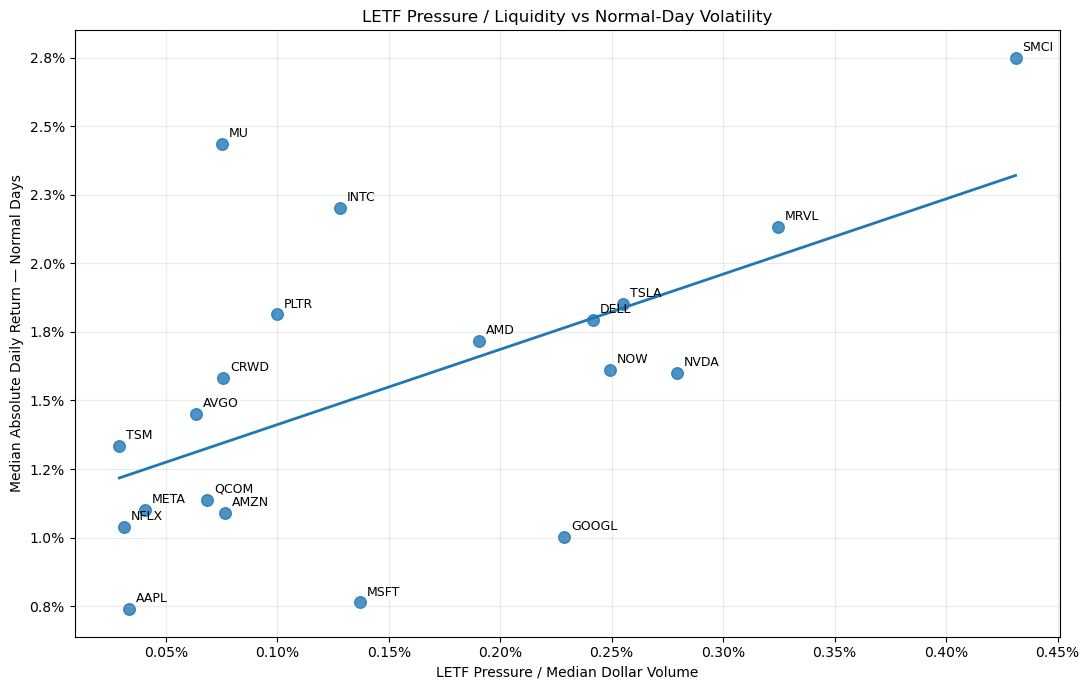

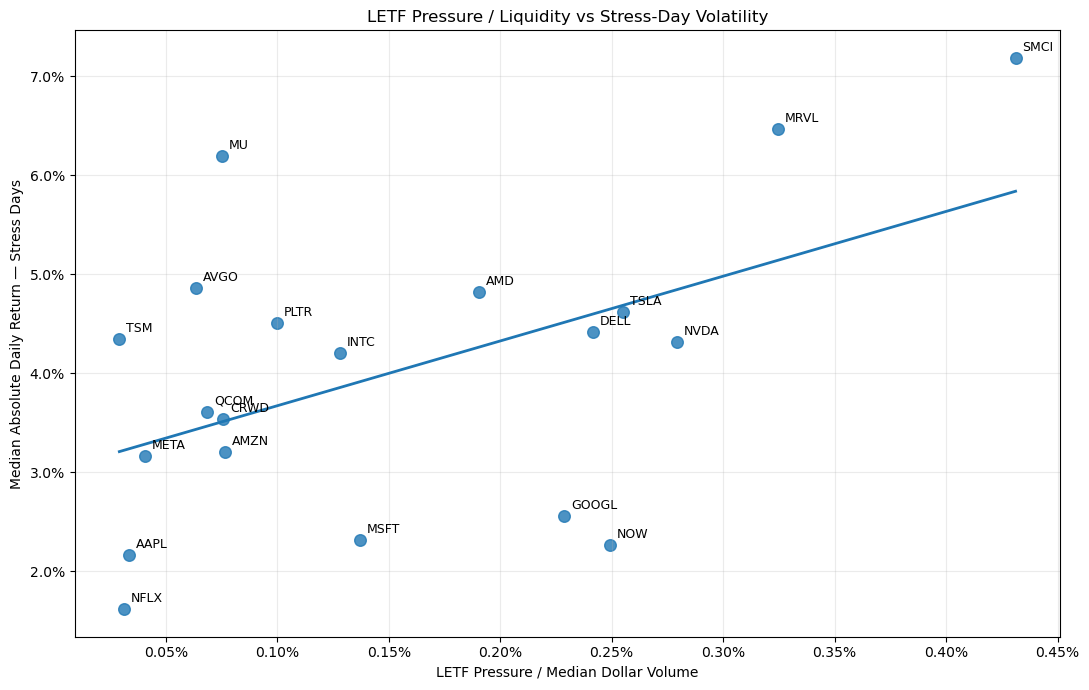


LETF PRESSURE / LIQUIDITY vs VOLATILITY
Normal Days  — Pearson correlation: 0.575
Stress Days  — Pearson correlation: 0.505
Zmiana korelacji Stress vs Normal: -0.070


In [47]:
# WYKRESY — LETF PRESSURE / LIQUIDITY vs VOLATILITY

# 1. PRZYGOTOWANIE DANYCH

plot_data = inception_stress[
    [
        "Underlying",
        "Pressure / Median Volume",
        "Normal Median Abs Return",
        "Stress Median Abs Return"
    ]
].dropna().copy()


x = plot_data["Pressure / Median Volume"].values


# 2. FUNKCJA DO WYKRESU

def make_scatter_plot(
    x,
    y,
    ticker_labels,
    title,
    y_label
):

    # Korelacja Pearsona
    correlation = np.corrcoef(x, y)[0, 1]


    # Regresja liniowa
    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

    x_line = np.linspace(
        x.min(),
        x.max(),
        100
    )

    y_line = (
        slope * x_line
        + intercept
    )


    # Wykres
    fig, ax = plt.subplots(
        figsize=(11, 7)
    )


    ax.scatter(
        x,
        y,
        s=70,
        alpha=0.8
    )


    # Linia regresji
    ax.plot(
        x_line,
        y_line,
        linewidth=2
    )


    # Etykiety spółek
    for xi, yi, label in zip(
        x,
        y,
        ticker_labels
    ):

        ax.annotate(
            label,
            (xi, yi),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    # Format osi
    ax.xaxis.set_major_formatter(
        PercentFormatter(
            xmax=1,
            decimals=2
        )
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(
            xmax=1,
            decimals=1
        )
    )

    # Opisy
    ax.set_xlabel(
        "LETF Pressure / Median Dollar Volume"
    )

    ax.set_ylabel(
        y_label
    )

    ax.set_title(
        f"{title}"
    )


    ax.grid(
        alpha=0.25
    )


    plt.tight_layout()

    plt.show()


    return correlation


# 3. NORMAL DAYS

corr_normal = make_scatter_plot(
    x=x,
    y=plot_data[
        "Normal Median Abs Return"
    ].values,

    ticker_labels=plot_data[
        "Underlying"
    ].values,

    title=(
        "LETF Pressure / Liquidity vs "
        "Normal-Day Volatility"
    ),

    y_label=(
        "Median Absolute Daily Return — Normal Days"
    )
)


# 4. STRESS DAYS

corr_stress = make_scatter_plot(
    x=x,
    y=plot_data[
        "Stress Median Abs Return"
    ].values,

    ticker_labels=plot_data[
        "Underlying"
    ].values,

    title=(
        "LETF Pressure / Liquidity vs "
        "Stress-Day Volatility"
    ),

    y_label=(
        "Median Absolute Daily Return — Stress Days"
    )
)


# 5. PODSUMOWANIE KORELACJI

print("\n" + "=" * 90)
print("LETF PRESSURE / LIQUIDITY vs VOLATILITY")
print("=" * 90)

print(
    f"Normal Days  — Pearson correlation: "
    f"{corr_normal:.3f}"
)

print(
    f"Stress Days  — Pearson correlation: "
    f"{corr_stress:.3f}"
)

print(
    f"Zmiana korelacji Stress vs Normal: "
    f"{corr_stress - corr_normal:+.3f}"
)

In [49]:
# KROK 18: PRE-LETF vs POST-LETF

print("\n" + "=" * 110)
print("KROK 18 — PRE-LETF vs POST-LETF")
print("=" * 110)


# 1. PRZYGOTOWANIE QQQ STRESS DAYS

qqq = yf.download(
    "QQQ",
    start="2020-01-01",
    end="2026-08-07",
    auto_adjust=False,
    progress=False
)

# Obsługa ewentualnych MultiIndex columns
if isinstance(qqq.columns, pd.MultiIndex):
    qqq.columns = qqq.columns.get_level_values(0)


qqq = qqq.copy()

# Daty
qqq.index = pd.to_datetime(qqq.index)

if getattr(qqq.index, "tz", None) is not None:
    qqq.index = qqq.index.tz_localize(None)

# Dzienny zwrot QQQ
qqq["Return"] = qqq["Close"].pct_change()

qqq["Absolute Return"] = (
    qqq["Return"].abs()
)

# DEFINICJA MARKET STRESS
qqq_stress_threshold = (
    qqq["Absolute Return"]
    .dropna()
    .quantile(0.90)
)

# Stress days
qqq["QQQ Stress Day"] = (
    qqq["Absolute Return"]
    >= qqq_stress_threshold
)


# INFORMACJE KONTROLNE
print("\n" + "=" * 100)
print("DEFINICJA MARKET STRESS — QQQ")
print("=" * 100)

print(
    "Okres: 2020-01-01 → 2026-08-07"
)

print(
    f"Stress threshold: "
    f"{qqq_stress_threshold:.2%}"
)

print(
    f"Liczba obserwacji QQQ: "
    f"{qqq['Absolute Return'].count():,}"
)

print(
    f"Liczba stress days: "
    f"{qqq['QQQ Stress Day'].sum():,}"
)

print(
    f"Udział stress days: "
    f"{qqq['QQQ Stress Day'].mean():.2%}"
)

# 2. PRZYGOTOWANIE DAT PIERWSZEGO LETF
first_inception = first_inception.copy()

first_inception["First LETF Inception"] = pd.to_datetime(
    first_inception["First LETF Inception"]
)

# 3. ANALIZA KAŻDEJ SPÓŁKI
results = []


for ticker, data in price_data.items():

    # Sprawdzamy, czy spółka jest w naszej próbie
    if ticker not in first_inception["Underlying"].values:
        continue

    # Data pierwszego LETF
    inception_date = first_inception.loc[
        first_inception["Underlying"] == ticker,
        "First LETF Inception"
    ].iloc[0]

    # Przygotowanie danych spółki
    temp = data.copy()

    temp.index = pd.to_datetime(temp.index)

    if getattr(temp.index, "tz", None) is not None:
        temp.index = temp.index.tz_localize(None)

    # Jeśli Absolute Return nie istnieje, obliczamy go
    if "Absolute Return" not in temp.columns:

        temp["Return"] = temp["Close"].pct_change()

        temp["Absolute Return"] = (
            temp["Return"].abs()
        )

    # USUWAMY EWENTUALNE STARE KOLUMNY
    columns_to_remove = [
        "QQQ Stress Day"
    ]

    for col in columns_to_remove:

        if col in temp.columns:
            temp = temp.drop(columns=[col])

    # Dołączamy QQQ Stress Day
    temp = temp.join(
        qqq["QQQ Stress Day"],
        how="inner"
    )

    # PODZIAŁ NA PRE-LETF I POST-LETF
    pre = temp[
        temp.index < inception_date
    ].copy()


    post = temp[
        temp.index >= inception_date
    ].copy()

    # STATYSTYKI
    def calculate_period_stats(period_data):

        normal = period_data[
            period_data["QQQ Stress Day"] == False
        ]["Absolute Return"].dropna()


        stress = period_data[
            period_data["QQQ Stress Day"] == True
        ]["Absolute Return"].dropna()


        if len(normal) == 0 or len(stress) == 0:
            return None


        normal_median = normal.median()

        stress_median = stress.median()


        return {
            "Observations": len(period_data),

            "Normal Days": len(normal),

            "Stress Days": len(stress),

            "Normal Median":
                normal_median,

            "Stress Median":
                stress_median,

            "Stress Multiplier":
                stress_median / normal_median,

            "Normal Mean":
                normal.mean(),

            "Stress Mean":
                stress.mean()
        }


    # LICZYMY PRE I POST
    pre_stats = calculate_period_stats(pre)

    post_stats = calculate_period_stats(post)

    if pre_stats is None or post_stats is None:
        continue

    # ZMIANY PRE → POST
    stress_multiplier_change = (
        post_stats["Stress Multiplier"]
        - pre_stats["Stress Multiplier"]
    )


    stress_multiplier_change_pct = (
        post_stats["Stress Multiplier"]
        / pre_stats["Stress Multiplier"]
        - 1
    )


    normal_volatility_change_pct = (
        post_stats["Normal Median"]
        / pre_stats["Normal Median"]
        - 1
    )


    stress_volatility_change_pct = (
        post_stats["Stress Median"]
        / pre_stats["Stress Median"]
        - 1
    )


    # WYNIKI
    results.append({

        "Underlying": ticker,

        "First LETF Inception":
            inception_date,

        # PRE
        "PRE Observations":
            pre_stats["Observations"],

        "PRE Normal Days":
            pre_stats["Normal Days"],

        "PRE Stress Days":
            pre_stats["Stress Days"],

        "PRE Normal Median":
            pre_stats["Normal Median"],

        "PRE Stress Median":
            pre_stats["Stress Median"],

        "PRE Stress Multiplier":
            pre_stats["Stress Multiplier"],

        # POST
        "POST Observations":
            post_stats["Observations"],

        "POST Normal Days":
            post_stats["Normal Days"],

        "POST Stress Days":
            post_stats["Stress Days"],

        "POST Normal Median":
            post_stats["Normal Median"],

        "POST Stress Median":
            post_stats["Stress Median"],

        "POST Stress Multiplier":
            post_stats["Stress Multiplier"],

        # ZMIANA
        "Stress Multiplier Change":
            stress_multiplier_change,

        "Stress Multiplier Change %":
            stress_multiplier_change_pct,

        "Normal Volatility Change %":
            normal_volatility_change_pct,

        "Stress Volatility Change %":
            stress_volatility_change_pct
    })


# 4. UTWORZENIE DATAFRAME

pre_post = pd.DataFrame(results)


# 5. DOŁĄCZENIE LETF EXPOSURE

pre_post = pre_post.merge(
    analysis[
        [
            "Underlying",
            "Pressure / Median Volume"
        ]
    ],
    on="Underlying",
    how="left"
)


# 6. SORTOWANIE

pre_post = pre_post.sort_values(
    "Stress Multiplier Change",
    ascending=False
).reset_index(drop=True)


# 7. WYNIKI

print("\n" + "=" * 150)
print("PRE-LETF vs POST-LETF — ZMIANA CHARAKTERYSTYKI ZMIENNOŚCI")
print("=" * 150)


print(
    f"{'Underlying':<10}"
    f"{'LETF Inception':>15}"
    f"{'PRE Stress':>14}"
    f"{'POST Stress':>14}"
    f"{'PRE Mult.':>12}"
    f"{'POST Mult.':>13}"
    f"{'Change':>12}"
    f"{'Change %':>12}"
    f"{'Pressure/Liq.':>16}"
)

print("-" * 150)


for _, row in pre_post.iterrows():

    print(
        f"{row['Underlying']:<10}"
        f"{row['First LETF Inception'].strftime('%Y-%m-%d'):>15}"
        f"{row['PRE Stress Median']:>13.2%}"
        f"{row['POST Stress Median']:>13.2%}"
        f"{row['PRE Stress Multiplier']:>11.2f}x"
        f"{row['POST Stress Multiplier']:>12.2f}x"
        f"{row['Stress Multiplier Change']:>11.2f}x"
        f"{row['Stress Multiplier Change %']:>11.1%}"
        f"{row['Pressure / Median Volume']:>15.4%}"
    )


# 8. PODSUMOWANIE

print("\n" + "=" * 100)
print("PODSUMOWANIE PRE-LETF vs POST-LETF")
print("=" * 100)


print(
    f"Średni PRE Stress Multiplier:  "
    f"{pre_post['PRE Stress Multiplier'].mean():.2f}x"
)


print(
    f"Średni POST Stress Multiplier: "
    f"{pre_post['POST Stress Multiplier'].mean():.2f}x"
)


print(
    f"Średnia zmiana: "
    f"{pre_post['Stress Multiplier Change'].mean():+.2f}x"
)


print(
    f"Mediana zmiany: "
    f"{pre_post['Stress Multiplier Change'].median():+.2f}x"
)


print(
    f"Średnia zmiana procentowa: "
    f"{pre_post['Stress Multiplier Change %'].mean():+.1%}"
)


print(
    f"Spółki z wyższym Stress Multiplier POST: "
    f"{(pre_post['Stress Multiplier Change'] > 0).sum()}"
    f"/{len(pre_post)}"
)


# 9. KORELACJE

print("\n" + "=" * 100)
print("KORELACJE — LETF EXPOSURE vs ZMIANA PO WPROWADZENIU LETF")
print("=" * 100)


correlations_pre_post = pre_post[
    [
        "Pressure / Median Volume",
        "Stress Multiplier Change",
        "Stress Multiplier Change %",
        "Normal Volatility Change %",
        "Stress Volatility Change %"
    ]
].corr()


print(
    correlations_pre_post.to_string(
        float_format=lambda x: f"{x:.3f}"
    )
)


KROK 18 — PRE-LETF vs POST-LETF

DEFINICJA MARKET STRESS — QQQ
Okres: 2020-01-01 → 2026-08-07
Stress threshold: 2.38%
Liczba obserwacji QQQ: 1,656
Liczba stress days: 166
Udział stress days: 10.02%

PRE-LETF vs POST-LETF — ZMIANA CHARAKTERYSTYKI ZMIENNOŚCI
Underlying LETF Inception    PRE Stress   POST Stress   PRE Mult.   POST Mult.      Change    Change %   Pressure/Liq.
------------------------------------------------------------------------------------------------------------------------------------------------------
SMCI           2024-08-21        3.05%        7.74%       1.72x        2.75x       1.03x      59.8%        0.4312%
TSM            2024-11-11        3.18%        5.03%       2.68x        3.64x       0.96x      35.7%        0.0292%
QCOM           2025-02-13        3.94%        4.29%       3.16x        3.69x       0.53x      16.8%        0.0685%
MRVL           2025-03-07        5.30%        8.13%       3.20x        3.73x       0.53x      16.4%        0.3245%
PLTR        

In [51]:
# KROK 19: HIGH vs LOW LETF EXPOSURE — INCEPTION-AWARE (HIGH EXPOSURE = TOP 10; LOW EXPOSURE  = BOTTOM 10)
# Każda spółka jest analizowana dopiero od momentu pojawienia się pierwszego LETF według Pressure / Median Volume

print("\n" + "=" * 110)
print("KROK 19 — HIGH vs LOW LETF EXPOSURE — INCEPTION-AWARE")
print("=" * 110)


# 1. PRZYGOTOWANIE GRUP

exposure = analysis[
    [
        "Underlying",
        "Pressure / Median Volume"
    ]
].copy()


exposure = exposure.sort_values(
    "Pressure / Median Volume",
    ascending=False
).reset_index(drop=True)


# TOP 10 = HIGH
high_tickers = exposure.head(10)["Underlying"].tolist()

# BOTTOM 10 = LOW
low_tickers = exposure.tail(10)["Underlying"].tolist()


print("\nHIGH LETF EXPOSURE — TOP 10:")
print(", ".join(high_tickers))

print("\nLOW LETF EXPOSURE — BOTTOM 10:")
print(", ".join(low_tickers))


# 2. QQQ STRESS DAYS

qqq = qqq.copy()

qqq.index = pd.to_datetime(qqq.index)

if getattr(qqq.index, "tz", None) is not None:
    qqq.index = qqq.index.tz_localize(None)

if "Absolute Return" not in qqq.columns:

    qqq["Return"] = qqq["Close"].pct_change()

    qqq["Absolute Return"] = qqq["Return"].abs()


qqq_stress_threshold = (
    qqq["Absolute Return"]
    .dropna()
    .quantile(0.90)
)


qqq["QQQ Stress Day"] = (
    qqq["Absolute Return"]
    >= qqq_stress_threshold
)

# 3. DATY PIERWSZEGO LETF

first_inception = first_inception.copy()

first_inception["First LETF Inception"] = pd.to_datetime(
    first_inception["First LETF Inception"]
)


# 4. FUNKCJA BUDUJĄCA DANE DLA SPÓŁKI

def prepare_stock_data(ticker):

    if ticker not in price_data:
        return None

    if ticker not in first_inception["Underlying"].values:
        return None


    # Data pierwszego LETF
    inception_date = first_inception.loc[
        first_inception["Underlying"] == ticker,
        "First LETF Inception"
    ].iloc[0]


    temp = price_data[ticker].copy()

    temp.index = pd.to_datetime(temp.index)

    if getattr(temp.index, "tz", None) is not None:
        temp.index = temp.index.tz_localize(None)


    # Obliczenie Absolute Return
    if "Absolute Return" not in temp.columns:

        temp["Return"] = temp["Close"].pct_change()

        temp["Absolute Return"] = (
            temp["Return"].abs()
        )


    # Usuwamy ewentualną starą kolumnę stress
    if "QQQ Stress Day" in temp.columns:

        temp = temp.drop(
            columns=["QQQ Stress Day"]
        )


    # Dołączamy QQQ Stress Day
    temp = temp.join(
        qqq["QQQ Stress Day"],
        how="inner"
    )

    # tylko od momentu pierwszego LETF
    temp = temp[
        temp.index >= inception_date
    ].copy()


    return temp


# 5. STATYSTYKI

def calculate_stats(tickers):

    normal_returns = []
    stress_returns = []

    stock_stats = []


    for ticker in tickers:

        temp = prepare_stock_data(ticker)

        if temp is None:
            continue


        normal = temp[
            temp["QQQ Stress Day"] == False
        ]["Absolute Return"].dropna()


        stress = temp[
            temp["QQQ Stress Day"] == True
        ]["Absolute Return"].dropna()


        if len(normal) == 0 or len(stress) == 0:
            continue


        normal_returns.extend(
            normal.tolist()
        )

        stress_returns.extend(
            stress.tolist()
        )


        stock_stats.append({

            "Underlying": ticker,

            "Normal Days": len(normal),

            "Stress Days": len(stress),

            "Normal Median":
                normal.median(),

            "Stress Median":
                stress.median(),

            "Stress Multiplier":
                stress.median() / normal.median()
        })


    # Statystyki całej grupy
    normal_returns = pd.Series(
        normal_returns
    )

    stress_returns = pd.Series(
        stress_returns
    )


    return {

        "Normal Days": len(normal_returns),

        "Stress Days": len(stress_returns),

        "Normal Median":
            normal_returns.median(),

        "Normal Mean":
            normal_returns.mean(),

        "Stress Median":
            stress_returns.median(),

        "Stress Mean":
            stress_returns.mean(),

        "Stress Multiplier":
            stress_returns.median()
            / normal_returns.median(),

        "Stock Stats":
            pd.DataFrame(stock_stats)
    }


# 6. OBLICZENIA HIGH vs LOW

high_stats = calculate_stats(
    high_tickers
)

low_stats = calculate_stats(
    low_tickers
)


# 7. RÓŻNICE HIGH vs LOW

normal_median_difference = (
    high_stats["Normal Median"]
    / low_stats["Normal Median"]
    - 1
)


stress_median_difference = (
    high_stats["Stress Median"]
    / low_stats["Stress Median"]
    - 1
)


stress_multiplier_difference = (
    high_stats["Stress Multiplier"]
    - low_stats["Stress Multiplier"]
)


stress_multiplier_difference_pct = (
    high_stats["Stress Multiplier"]
    / low_stats["Stress Multiplier"]
    - 1
)


# 8. WYNIKI

print("\n" + "=" * 125)
print("HIGH LETF EXPOSURE vs LOW LETF EXPOSURE")
print("=" * 125)


print(
    f"{'Exposure Group':<22}"
    f"{'Normal Days':>14}"
    f"{'Stress Days':>14}"
    f"{'Normal Median':>18}"
    f"{'Stress Median':>18}"
    f"{'Stress Multiplier':>20}"
)

print("-" * 125)


print(
    f"{'HIGH LETF Exposure':<22}"
    f"{high_stats['Normal Days']:>14,}"
    f"{high_stats['Stress Days']:>14,}"
    f"{high_stats['Normal Median']:>17.2%}"
    f"{high_stats['Stress Median']:>17.2%}"
    f"{high_stats['Stress Multiplier']:>19.2f}x"
)


print(
    f"{'LOW LETF Exposure':<22}"
    f"{low_stats['Normal Days']:>14,}"
    f"{low_stats['Stress Days']:>14,}"
    f"{low_stats['Normal Median']:>17.2%}"
    f"{low_stats['Stress Median']:>17.2%}"
    f"{low_stats['Stress Multiplier']:>19.2f}x"
)


# 9. RÓŻNICA HIGH vs LOW

print("\n" + "=" * 100)
print("RÓŻNICA HIGH vs LOW")
print("=" * 100)


print(
    f"Normal Median Abs Return — HIGH vs LOW: "
    f"{normal_median_difference:+.1%}"
)


print(
    f"Stress Median Abs Return — HIGH vs LOW: "
    f"{stress_median_difference:+.1%}"
)


print(
    f"Stress Multiplier — HIGH minus LOW: "
    f"{stress_multiplier_difference:+.2f}x"
)


print(
    f"Stress Multiplier — HIGH vs LOW: "
    f"{stress_multiplier_difference_pct:+.1%}"
)


# 10. STATYSTYKI POJEDYNCZYCH SPÓŁEK

stock_stats_high = high_stats["Stock Stats"].copy()

stock_stats_high["Exposure Group"] = "HIGH"


stock_stats_low = low_stats["Stock Stats"].copy()

stock_stats_low["Exposure Group"] = "LOW"


stock_stats_all = pd.concat(
    [
        stock_stats_high,
        stock_stats_low
    ],
    ignore_index=True
)


stock_stats_all = stock_stats_all.sort_values(
    [
        "Exposure Group",
        "Stress Multiplier"
    ],
    ascending=[True, False]
)


print("\n" + "=" * 110)
print("STRESS MULTIPLIER — POSZCZEGÓLNE SPÓŁKI")
print("=" * 110)


print(
    stock_stats_all[
        [
            "Exposure Group",
            "Underlying",
            "Normal Median",
            "Stress Median",
            "Stress Multiplier"
        ]
    ].to_string(
        index=False,
        formatters={
            "Normal Median":
                "{:.2%}".format,

            "Stress Median":
                "{:.2%}".format,

            "Stress Multiplier":
                "{:.2f}x".format
        }
    )
)


KROK 19 — HIGH vs LOW LETF EXPOSURE — INCEPTION-AWARE

HIGH LETF EXPOSURE — TOP 10:
SMCI, MRVL, NVDA, TSLA, NOW, DELL, GOOGL, AMD, MSFT, INTC

LOW LETF EXPOSURE — BOTTOM 10:
PLTR, AMZN, CRWD, MU, QCOM, AVGO, META, AAPL, NFLX, TSM

HIGH LETF EXPOSURE vs LOW LETF EXPOSURE
Exposure Group           Normal Days   Stress Days     Normal Median     Stress Median   Stress Multiplier
-----------------------------------------------------------------------------------------------------------------------------
HIGH LETF Exposure             5,923           423            1.51%            4.02%               2.67x
LOW LETF Exposure              5,603           407            1.21%            3.65%               3.01x

RÓŻNICA HIGH vs LOW
Normal Median Abs Return — HIGH vs LOW: +24.3%
Stress Median Abs Return — HIGH vs LOW: +10.1%
Stress Multiplier — HIGH minus LOW: -0.35x
Stress Multiplier — HIGH vs LOW: -11.5%

STRESS MULTIPLIER — POSZCZEGÓLNE SPÓŁKI
Exposure Group Underlying Normal Median Stress

In [53]:
# KROK 20 — KIERUNKOWY TEST PROCYKLICZNEGO REBALANCINGU - czy większa ekspozycja LETF wiąże się z większym ruchem spółki w tym samym kierunku co QQQ?

print("\n" + "=" * 110)
print("KROK 20 — KIERUNKOWY TEST PROCYKLICZNEGO REBALANCINGU")
print("=" * 110)


# 1. PRZYGOTOWANIE QQQ

qqq_test = qqq.copy()

qqq_test.index = pd.to_datetime(qqq_test.index)

if getattr(qqq_test.index, "tz", None) is not None:
    qqq_test.index = qqq_test.index.tz_localize(None)


qqq_test["QQQ Return"] = (
    qqq_test["Close"].pct_change()
)


# usuwamy dni bez zwrotu
qqq_test = qqq_test.dropna(
    subset=["QQQ Return"]
)


# 2. FUNKCJA PRZYGOTOWUJĄCA SPÓŁKĘ

def prepare_directional_stock(ticker):

    if ticker not in price_data:
        return None

    if ticker not in first_inception["Underlying"].values:
        return None


    inception_date = first_inception.loc[
        first_inception["Underlying"] == ticker,
        "First LETF Inception"
    ].iloc[0]


    temp = price_data[ticker].copy()

    temp.index = pd.to_datetime(temp.index)

    if getattr(temp.index, "tz", None) is not None:
        temp.index = temp.index.tz_localize(None)


    temp["Stock Return"] = (
        temp["Close"].pct_change()
    )

    # Tylko okres POST-LETF
    temp = temp[
        temp.index >= inception_date
    ].copy()


    # Łączymy z QQQ
    temp = temp.join(
        qqq_test[["QQQ Return"]],
        how="inner"
    )


    temp = temp.dropna(
        subset=[
            "Stock Return",
            "QQQ Return"
        ]
    )


    return temp


# 3. OBLICZENIA DLA KAŻDEJ SPÓŁKI
directional_results = []


for _, row in analysis.iterrows():

    ticker = row["Underlying"]

    pressure = row[
        "Pressure / Median Volume"
    ]


    temp = prepare_directional_stock(
        ticker
    )


    if temp is None or len(temp) == 0:
        continue


    # UP DAYS
    up_days = temp[
        temp["QQQ Return"] > 0
    ].copy()


    # DOWN DAYS
    down_days = temp[
        temp["QQQ Return"] < 0
    ].copy()

    # Dla UP DAYS: średni zwrot spółki oraz relacja stock / QQQ
    up_stock_return = (
        up_days["Stock Return"].mean()
    )

    up_qqq_return = (
        up_days["QQQ Return"].mean()
    )


    up_same_direction = (
        (
            up_days["Stock Return"] > 0
        ).mean()
    )


    # Dla DOWN DAYS
    down_stock_return = (
        down_days["Stock Return"].mean()
    )

    down_qqq_return = (
        down_days["QQQ Return"].mean()
    )


    down_same_direction = (
        (
            down_days["Stock Return"] < 0
        ).mean()
    )

    # Absolutna przewaga ruchu - Ile razy średni ruch spółki jest większy od ruchu QQQ w tym samym kierunku?

    up_amplification = (
        up_stock_return
        / up_qqq_return
        if up_qqq_return != 0
        else np.nan
    )


    down_amplification = (
        abs(down_stock_return)
        / abs(down_qqq_return)
        if down_qqq_return != 0
        else np.nan
    )


    directional_results.append({

        "Underlying": ticker,

        "Pressure / Median Volume":
            pressure,

        "Up Days":
            len(up_days),

        "Down Days":
            len(down_days),

        "Mean Stock Return Up":
            up_stock_return,

        "Mean QQQ Return Up":
            up_qqq_return,

        "Same Direction Up":
            up_same_direction,

        "Up Amplification":
            up_amplification,

        "Mean Stock Return Down":
            down_stock_return,

        "Mean QQQ Return Down":
            down_qqq_return,

        "Same Direction Down":
            down_same_direction,

        "Down Amplification":
            down_amplification
    })


directional_results = pd.DataFrame(
    directional_results
)


# 4. KORELACJE

corr_up = directional_results[
    [
        "Pressure / Median Volume",
        "Up Amplification"
    ]
].corr().iloc[0, 1]


corr_down = directional_results[
    [
        "Pressure / Median Volume",
        "Down Amplification"
    ]
].corr().iloc[0, 1]


corr_up_direction = directional_results[
    [
        "Pressure / Median Volume",
        "Same Direction Up"
    ]
].corr().iloc[0, 1]


corr_down_direction = directional_results[
    [
        "Pressure / Median Volume",
        "Same Direction Down"
    ]
].corr().iloc[0, 1]


# 5. WYNIKI

print("\n" + "=" * 125)
print("KIERUNKOWE ZACHOWANIE SPÓŁEK — POST LETF")
print("=" * 125)


print(
    f"{'Underlying':<10}"
    f"{'Pressure/Liq.':>16}"
    f"{'Up Ampl.':>14}"
    f"{'Down Ampl.':>14}"
    f"{'Same Up':>14}"
    f"{'Same Down':>14}"
)

print("-" * 125)


display_df = directional_results.sort_values(
    "Pressure / Median Volume",
    ascending=False
)


for _, row in display_df.iterrows():

    print(
        f"{row['Underlying']:<10}"
        f"{row['Pressure / Median Volume']:>15.4%}"
        f"{row['Up Amplification']:>13.2f}x"
        f"{row['Down Amplification']:>13.2f}x"
        f"{row['Same Direction Up']:>13.1%}"
        f"{row['Same Direction Down']:>13.1%}"
    )


# 6. KORELACJE

print("\n" + "=" * 100)
print("KORELACJE — LETF EXPOSURE vs KIERUNKOWY RUCH")
print("=" * 100)


print(
    f"Pressure/Liquidity vs Up Amplification: "
    f"{corr_up:.3f}"
)

print(
    f"Pressure/Liquidity vs Down Amplification: "
    f"{corr_down:.3f}"
)

print(
    f"Pressure/Liquidity vs Same Direction Up: "
    f"{corr_up_direction:.3f}"
)

print(
    f"Pressure/Liquidity vs Same Direction Down: "
    f"{corr_down_direction:.3f}"
)


KROK 20 — KIERUNKOWY TEST PROCYKLICZNEGO REBALANCINGU

KIERUNKOWE ZACHOWANIE SPÓŁEK — POST LETF
Underlying   Pressure/Liq.      Up Ampl.    Down Ampl.       Same Up     Same Down
-----------------------------------------------------------------------------------------------------------------------------
SMCI              0.4312%         2.44x         2.80x        64.7%        78.9%
MRVL              0.3245%         2.36x         2.05x        73.3%        74.0%
NVDA              0.2791%         1.96x         1.69x        78.5%        76.3%
TSLA              0.2549%         1.68x         1.84x        70.2%        73.7%
NOW               0.2493%         0.19x         0.55x        54.0%        56.8%
DELL              0.2416%         1.88x         1.27x        68.9%        69.1%
GOOGL             0.2287%         1.03x         0.94x        75.0%        73.1%
AMD               0.1906%         2.01x         1.92x        72.7%        76.6%
MSFT              0.1372%         0.86x         0.87x 

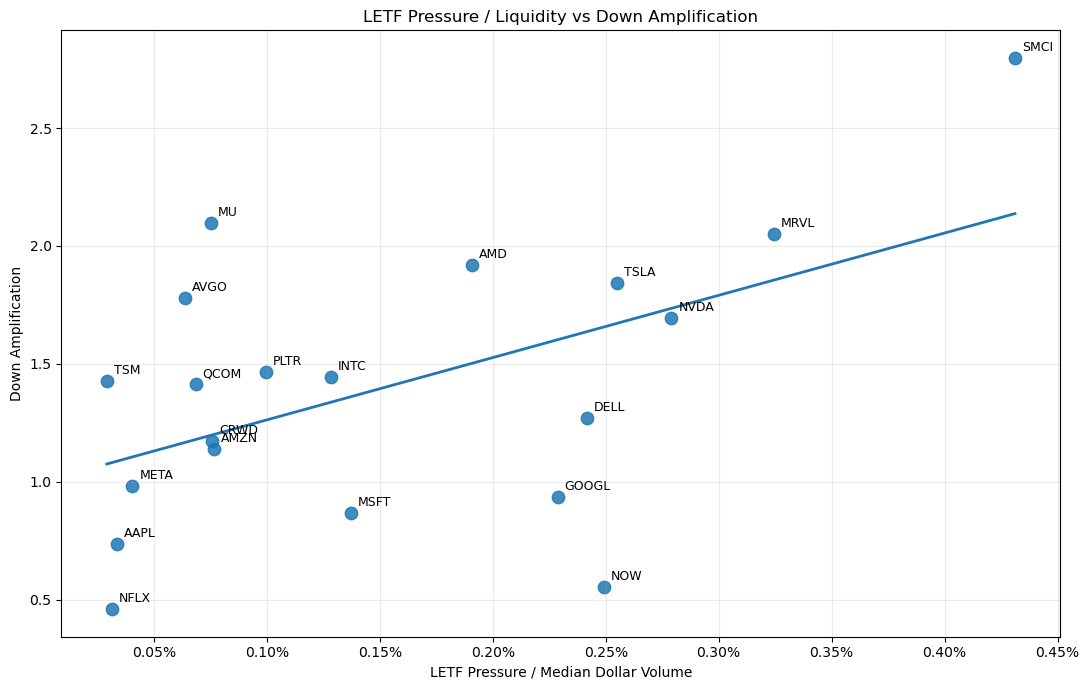


LETF PRESSURE / LIQUIDITY vs DOWN AMPLIFICATION
Pearson correlation: 0.522


In [55]:
# WYKRES — LETF PRESSURE / LIQUIDITY vs DOWN AMPLIFICATION
# Okres = POST-LETF

# 1. PRZYGOTOWANIE DANYCH

plot_directional = directional_results[
    [
        "Underlying",
        "Pressure / Median Volume",
        "Down Amplification"
    ]
].dropna().copy()


x = plot_directional[
    "Pressure / Median Volume"
].values


y = plot_directional[
    "Down Amplification"
].values


labels = plot_directional[
    "Underlying"
].values


# 2. KORELACJA

correlation = np.corrcoef(
    x,
    y
)[0, 1]


# 3. REGRESJA LINIOWA

slope, intercept = np.polyfit(
    x,
    y,
    1
)


x_line = np.linspace(
    x.min(),
    x.max(),
    100
)


y_line = (
    slope * x_line
    + intercept
)


# 4. WYKRES

fig, ax = plt.subplots(
    figsize=(11, 7)
)


# Punkty
ax.scatter(
    x,
    y,
    s=80,
    alpha=0.85
)


# Linia regresji
ax.plot(
    x_line,
    y_line,
    linewidth=2
)


# Etykiety spółek
for xi, yi, label in zip(
    x,
    y,
    labels
):

    ax.annotate(
        label,
        (xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# 5. FORMATOWANIE OSI

ax.xaxis.set_major_formatter(
    PercentFormatter(
        xmax=1,
        decimals=2
    )
)

# 6. OPISY

ax.set_xlabel(
    "LETF Pressure / Median Dollar Volume"
)


ax.set_ylabel(
    "Down Amplification"
)


ax.set_title(
    "LETF Pressure / Liquidity vs Down Amplification"
)


# 7. SIATKA

ax.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# 8. OUTPUT

print("\n" + "=" * 90)
print("LETF PRESSURE / LIQUIDITY vs DOWN AMPLIFICATION")
print("=" * 90)

print(
    f"Pearson correlation: {correlation:.3f}"
)

In [57]:
# KROK 21 — KIERUNKOWY TEST PROCYKLICZNEGO REBALANCINGU WYŁĄCZNIE PODCZAS QQQ STRESS DAYS

print("\n" + "=" * 115)
print("KROK 21 — KIERUNKOWY TEST PROCYKLICZNEGO REBALANCINGU — QQQ STRESS DAYS")
print("=" * 115)

# 1. DANE QQQ

qqq_stress_test = qqq[["Close"]].copy()

qqq_stress_test.index = pd.to_datetime(
    qqq_stress_test.index
)

if getattr(qqq_stress_test.index, "tz", None) is not None:
    qqq_stress_test.index = (
        qqq_stress_test.index.tz_localize(None)
    )

# 2. DZIENNY ZWROT QQQ

qqq_stress_test["QQQ Return"] = (
    qqq_stress_test["Close"].pct_change()
)

# 3. STRESS THRESHOLD

qqq_stress_threshold = (
    qqq_stress_test["QQQ Return"]
    .abs()
    .dropna()
    .quantile(0.90)
)


qqq_stress_test["QQQ Stress Day"] = (
    qqq_stress_test["QQQ Return"].abs()
    >= qqq_stress_threshold
)


print(
    f"\nQQQ stress threshold: "
    f"{qqq_stress_threshold:.2%}"
)

print(
    f"Liczba QQQ stress days: "
    f"{qqq_stress_test['QQQ Stress Day'].sum():,}"
)


# 4. FUNKCJA PRZYGOTOWUJĄCA SPÓŁKĘ

def prepare_stress_directional_stock(ticker):

    if ticker not in price_data:
        return None

    if ticker not in first_inception["Underlying"].values:
        return None


    inception_date = first_inception.loc[
        first_inception["Underlying"] == ticker,
        "First LETF Inception"
    ].iloc[0]


    temp = price_data[ticker].copy()

    temp.index = pd.to_datetime(
        temp.index
    )

    if getattr(temp.index, "tz", None) is not None:
        temp.index = temp.index.tz_localize(None)


    # Zwrot spółki
    temp["Stock Return"] = (
        temp["Close"].pct_change()
    )


    # Usuwamy ewentualne stare kolumny QQQ
    columns_to_drop = [
        "QQQ Return",
        "QQQ Stress Day"
    ]

    temp = temp.drop(
        columns=[
            col
            for col in columns_to_drop
            if col in temp.columns
        ]
    )


    # Łączymy ze świeżymi danymi QQQ
    temp = temp.join(
        qqq_stress_test[
            [
                "QQQ Return",
                "QQQ Stress Day"
            ]
        ],
        how="inner"
    )


    # Tylko okres POST-LETF
    temp = temp[
        temp.index >= inception_date
    ].copy()


    temp = temp.dropna(
        subset=[
            "Stock Return",
            "QQQ Return"
        ]
    )


    # Tylko stress days
    temp = temp[
        temp["QQQ Stress Day"]
    ].copy()


    return temp


# 5. OBLICZENIA DLA KAŻDEJ SPÓŁKI

stress_directional_results = []


for _, row in analysis.iterrows():

    ticker = row["Underlying"]

    pressure = row[
        "Pressure / Median Volume"
    ]


    temp = prepare_stress_directional_stock(
        ticker
    )


    if temp is None or len(temp) == 0:
        continue


    # STRESS UP DAYS
    stress_up = temp[
        temp["QQQ Return"] > 0
    ].copy()

    # STRESS DOWN DAYS
    stress_down = temp[
        temp["QQQ Return"] < 0
    ].copy()


    # UP
    if len(stress_up) > 0:

        mean_stock_up = (
            stress_up["Stock Return"].mean()
        )

        mean_qqq_up = (
            stress_up["QQQ Return"].mean()
        )

        up_amplification = (
            mean_stock_up / mean_qqq_up
            if mean_qqq_up != 0
            else np.nan
        )

        same_direction_up = (
            stress_up["Stock Return"] > 0
        ).mean()

    else:

        up_amplification = np.nan
        same_direction_up = np.nan


    # DOWN
    if len(stress_down) > 0:

        mean_stock_down = (
            stress_down["Stock Return"].mean()
        )

        mean_qqq_down = (
            stress_down["QQQ Return"].mean()
        )

        down_amplification = (
            abs(mean_stock_down)
            / abs(mean_qqq_down)
            if mean_qqq_down != 0
            else np.nan
        )

        same_direction_down = (
            stress_down["Stock Return"] < 0
        ).mean()

    else:

        down_amplification = np.nan
        same_direction_down = np.nan

    # ZAPIS
    stress_directional_results.append({

        "Underlying": ticker,

        "Pressure / Median Volume":
            pressure,

        "Stress Up Days":
            len(stress_up),

        "Stress Down Days":
            len(stress_down),

        "Stress Up Amplification":
            up_amplification,

        "Stress Down Amplification":
            down_amplification,

        "Stress Same Direction Up":
            same_direction_up,

        "Stress Same Direction Down":
            same_direction_down
    })


stress_directional_results = pd.DataFrame(
    stress_directional_results
)


# 6. KORELACJE

corr_stress_up = (
    stress_directional_results[
        [
            "Pressure / Median Volume",
            "Stress Up Amplification"
        ]
    ]
    .dropna()
    .corr()
    .iloc[0, 1]
)


corr_stress_down = (
    stress_directional_results[
        [
            "Pressure / Median Volume",
            "Stress Down Amplification"
        ]
    ]
    .dropna()
    .corr()
    .iloc[0, 1]
)


corr_stress_up_direction = (
    stress_directional_results[
        [
            "Pressure / Median Volume",
            "Stress Same Direction Up"
        ]
    ]
    .dropna()
    .corr()
    .iloc[0, 1]
)


corr_stress_down_direction = (
    stress_directional_results[
        [
            "Pressure / Median Volume",
            "Stress Same Direction Down"
        ]
    ]
    .dropna()
    .corr()
    .iloc[0, 1]
)

# 7. TABELA

print("\n" + "=" * 130)
print("KIERUNKOWE ZACHOWANIE SPÓŁEK — WYŁĄCZNIE QQQ STRESS DAYS")
print("=" * 130)


print(
    f"{'Underlying':<10}"
    f"{'Pressure/Liq.':>16}"
    f"{'Stress Up':>14}"
    f"{'Stress Down':>16}"
    f"{'Same Up':>14}"
    f"{'Same Down':>16}"
)

print("-" * 130)


display_df = stress_directional_results.sort_values(
    "Pressure / Median Volume",
    ascending=False
)


for _, row in display_df.iterrows():

    print(
        f"{row['Underlying']:<10}"
        f"{row['Pressure / Median Volume']:>15.4%}"
        f"{row['Stress Up Amplification']:>13.2f}x"
        f"{row['Stress Down Amplification']:>15.2f}x"
        f"{row['Stress Same Direction Up']:>13.1%}"
        f"{row['Stress Same Direction Down']:>15.1%}"
    )


# 8. KORELACJE

print("\n" + "=" * 105)
print("KORELACJE — LETF EXPOSURE vs KIERUNKOWY RUCH W STRESS DAYS")
print("=" * 105)


print(
    f"Pressure/Liquidity vs Stress Up Amplification: "
    f"{corr_stress_up:.3f}"
)

print(
    f"Pressure/Liquidity vs Stress Down Amplification: "
    f"{corr_stress_down:.3f}"
)

print(
    f"Pressure/Liquidity vs Same Direction Up: "
    f"{corr_stress_up_direction:.3f}"
)

print(
    f"Pressure/Liquidity vs Same Direction Down: "
    f"{corr_stress_down_direction:.3f}"
)


KROK 21 — KIERUNKOWY TEST PROCYKLICZNEGO REBALANCINGU — QQQ STRESS DAYS

QQQ stress threshold: 2.38%
Liczba QQQ stress days: 166

KIERUNKOWE ZACHOWANIE SPÓŁEK — WYŁĄCZNIE QQQ STRESS DAYS
Underlying   Pressure/Liq.     Stress Up     Stress Down       Same Up       Same Down
----------------------------------------------------------------------------------------------------------------------------------
SMCI              0.4312%         1.23x           1.96x        87.5%          89.5%
MRVL              0.3245%         2.40x           2.10x        92.9%         100.0%
NVDA              0.2791%         1.80x           1.82x       100.0%         100.0%
TSLA              0.2549%         1.52x           1.59x        97.1%          93.9%
NOW               0.2493%        -0.16x           0.38x        44.4%          50.0%
DELL              0.2416%         1.42x           1.42x        85.7%          92.3%
GOOGL             0.2287%         0.95x           0.96x        97.1%         100.0%
AMD   

In [59]:
# KROK 22 — BROAD-MARKET LETF (TQQQ / QLD / SOXL)

print("\n" + "=" * 110)
print("KROK 22 — BROAD-MARKET LETF")
print("=" * 110)

# 1. DEFINICJA BADANYCH LETF

broad_letf_symbols = [
    "TQQQ",
    "QLD",
    "SOXL"
]


# 2. WYBÓR ETF-ÓW Z BAZY

broad_letf = df[
    df["Symbol"].isin(broad_letf_symbols)
].copy()


# 3. PRZYPISANIE AKTYWA BAZOWEGO I DŹWIGNI

broad_metadata = {

    "TQQQ": {
        "Underlying": "QQQ",
        "Underlying Name": "Nasdaq-100",
        "Leverage": 3.0
    },

    "QLD": {
        "Underlying": "QQQ",
        "Underlying Name": "Nasdaq-100",
        "Leverage": 2.0
    },

    "SOXL": {
        "Underlying": "SOXX",
        "Underlying Name": "Semiconductors",
        "Leverage": 3.0
    }
}


broad_letf["Underlying"] = (
    broad_letf["Symbol"]
    .map(lambda x: broad_metadata[x]["Underlying"])
)

broad_letf["Underlying Name"] = (
    broad_letf["Symbol"]
    .map(lambda x: broad_metadata[x]["Underlying Name"])
)

broad_letf["Leverage"] = (
    broad_letf["Symbol"]
    .map(lambda x: broad_metadata[x]["Leverage"])
)


# 4. AUM
# W bazie ETFDB: Total Assets = tys. USD, Dlatego przeliczamy na pełne USD

broad_letf["AUM USD"] = (
    broad_letf["Total Assets"] * 1_000
)


# 5. NOMINALNA EKSPOZYCJA NA AKTYWO BAZOWE

broad_letf["Underlying Exposure USD"] = (
    broad_letf["AUM USD"]
    * broad_letf["Leverage"]
)


# 6. REBALANCING PRESSURE — 1% (Stosujemy dokładnie tę samą metodologię, którą wykorzystaliśmy wcześniej dla single-stock LETF:
# tj. Pressure = AUM × L × (L - 1) × market move

broad_letf["Rebalancing Pressure 1pct USD"] = (
    broad_letf["AUM USD"]
    * broad_letf["Leverage"]
    * (broad_letf["Leverage"] - 1)
    * 0.01
)


# 7. BAZA BROAD-MARKET LETF

print("\n" + "=" * 120)
print("BROAD-MARKET LETF — BAZA ANALIZY")
print("=" * 120)

print(
    f"{'Symbol':<8}"
    f"{'Underlying':<12}"
    f"{'Leverage':>10}"
    f"{'AUM':>20}"
    f"{'Underlying Exposure':>26}"
    f"{'Pressure 1%':>20}"
)

print("-" * 120)


for _, row in broad_letf.sort_values(
    "AUM USD",
    ascending=False
).iterrows():

    print(
        f"{row['Symbol']:<8}"
        f"{row['Underlying']:<12}"
        f"{row['Leverage']:>9.2f}x"
        f"${row['AUM USD']:>18,.0f}"
        f"${row['Underlying Exposure USD']:>24,.0f}"
        f"${row['Rebalancing Pressure 1pct USD']:>18,.0f}"
    )


# 8. PODSUMOWANIE WG AKTYWA BAZOWEGO

broad_summary = (
    broad_letf
    .groupby(
        ["Underlying", "Underlying Name"],
        as_index=False
    )
    .agg(
        LETF_Count=("Symbol", "count"),

        Total_AUM_USD=(
            "AUM USD",
            "sum"
        ),

        Total_Underlying_Exposure_USD=(
            "Underlying Exposure USD",
            "sum"
        ),

        Total_Rebalancing_Pressure_1pct_USD=(
            "Rebalancing Pressure 1pct USD",
            "sum"
        )
    )
)


print("\n" + "=" * 115)
print("BROAD-MARKET — ŁĄCZNA EKSPOZYCJA")
print("=" * 115)

print(
    f"{'Underlying':<12}"
    f"{'LETF Count':>12}"
    f"{'Total AUM':>20}"
    f"{'Underlying Exposure':>26}"
    f"{'Pressure 1%':>20}"
)

print("-" * 115)


for _, row in broad_summary.sort_values(
    "Total_Rebalancing_Pressure_1pct_USD",
    ascending=False
).iterrows():

    print(
        f"{row['Underlying']:<12}"
        f"{row['LETF_Count']:>11}"
        f"${row['Total_AUM_USD']:>18,.0f}"
        f"${row['Total_Underlying_Exposure_USD']:>24,.0f}"
        f"${row['Total_Rebalancing_Pressure_1pct_USD']:>18,.0f}"
    )


# 9. PRESJA DLA RÓŻNYCH RUCHÓW AKTYWA BAZOWEGO

for move in [0.01, 0.02, 0.03, 0.05]:

    column_name = (
        f"Pressure_{int(move * 100)}pct_USD"
    )

    broad_letf[column_name] = (
        broad_letf["AUM USD"]
        * broad_letf["Leverage"]
        * (broad_letf["Leverage"] - 1)
        * move
    )


# 10. TABELA PRESJI DLA RÓŻNYCH RUCHÓW

print("\n" + "=" * 130)
print(
    "POTENCJALNA PRESJA REBALANCINGOWA "
    "PRZY RÓŻNYCH RUCHACH AKTYWA BAZOWEGO"
)
print("=" * 130)

print(
    f"{'ETF':<8}"
    f"{'AUM':>20}"
    f"{'Lev.':>10}"
    f"{'+/-1%':>20}"
    f"{'+/-2%':>20}"
    f"{'+/-3%':>20}"
    f"{'+/-5%':>20}"
)

print("-" * 130)


for _, row in broad_letf.sort_values(
    "AUM USD",
    ascending=False
).iterrows():

    print(
        f"{row['Symbol']:<8}"
        f"${row['AUM USD']:>18,.0f}"
        f"{row['Leverage']:>9.1f}x"
        f"${row['Pressure_1pct_USD']:>18,.0f}"
        f"${row['Pressure_2pct_USD']:>18,.0f}"
        f"${row['Pressure_3pct_USD']:>18,.0f}"
        f"${row['Pressure_5pct_USD']:>18,.0f}"
    )


# 11. KONTROLA WYNIKÓW

print("\n" + "=" * 80)
print("KONTROLA — REBALANCING PRESSURE 1%")
print("=" * 80)

for _, row in broad_letf.sort_values(
    "Rebalancing Pressure 1pct USD",
    ascending=False
).iterrows():

    print(
        f"{row['Symbol']}: "
        f"${row['Rebalancing Pressure 1pct USD']:,.0f}"
    )


KROK 22 — BROAD-MARKET LETF

BROAD-MARKET LETF — BAZA ANALIZY
Symbol  Underlying    Leverage                 AUM       Underlying Exposure         Pressure 1%
------------------------------------------------------------------------------------------------------------------------
TQQQ    QQQ              3.00x$    36,576,600,000$         109,729,800,000$     2,194,596,000
SOXL    SOXX             3.00x$    22,373,800,000$          67,121,400,000$     1,342,428,000
QLD     QQQ              2.00x$    13,864,700,000$          27,729,400,000$       277,294,000

BROAD-MARKET — ŁĄCZNA EKSPOZYCJA
Underlying    LETF Count           Total AUM       Underlying Exposure         Pressure 1%
-------------------------------------------------------------------------------------------------------------------
QQQ                   2$    50,441,300,000$         137,459,200,000$     2,471,890,000
SOXX                  1$    22,373,800,000$          67,121,400,000$     1,342,428,000

POTENCJALNA PRESJA RE

In [63]:
# KROK 23 — BROAD-MARKET LETF PRESSURE vs LIQUIDITY (średnia i mediana wolumenu za ostatnie 12M)

print("\n" + "=" * 115)
print("KROK 23 — BROAD-MARKET LETF PRESSURE vs LIQUIDITY")
print("=" * 115)

# POBRANIE DANYCH QQQ I SOXX

broad_underlyings = [
    "QQQ",
    "SOXX"
]

for ticker in broad_underlyings:

    print(f"Pobieranie: {ticker}...")

    data = yf.download(
        ticker,
        start="2020-01-01",
        end="2026-08-07",
        auto_adjust=False,
        progress=False
    )

    if data.empty:

        print(f"  BRAK DANYCH: {ticker}")

    else:

        # yfinance w niektórych wersjach zwraca MultiIndex
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        data = data[
            ["Open", "High", "Low", "Close", "Volume"]
        ].copy()

        price_data[ticker] = data

        print(
            f"  OK: {len(data):,} obserwacji | "
            f"{data.index.min().date()} → "
            f"{data.index.max().date()}"
        )


# 1. PARAMETRY

end_date = pd.Timestamp("2026-08-06")

start_date = (
    end_date
    - pd.DateOffset(years=1)
)


# 2. BROAD-MARKET LETF

broad_pressure = {
    row["Underlying"]:
        row["Total_Rebalancing_Pressure_1pct_USD"]
    for _, row in broad_summary.iterrows()
}


broad_aum = {
    row["Underlying"]:
        row["Total_AUM_USD"]
    for _, row in broad_summary.iterrows()
}


broad_letf_count = {
    row["Underlying"]:
        row["LETF_Count"]
    for _, row in broad_summary.iterrows()
}


# 3. AKTYWA BAZOWE

broad_underlyings = [
    "QQQ",
    "SOXX"
]


# 4. PŁYNNOŚĆ AKTYWÓW BAZOWYCH

broad_liquidity_results = []


for ticker in broad_underlyings:

    print(
        f"Pobieranie danych płynności: {ticker}..."
    )

    # Sprawdzamy, czy ticker istnieje w price_data
    if ticker not in price_data:

        print(
            f"  BRAK DANYCH: {ticker}"
        )

        continue


    temp = price_data[ticker].copy()


    # Daty
    temp.index = pd.to_datetime(
        temp.index
    )


    if getattr(temp.index, "tz", None) is not None:

        temp.index = (
            temp.index.tz_localize(None)
        )


    # Ostatnie 12 miesięcy
    temp = temp[
        (temp.index >= start_date)
        &
        (temp.index <= end_date)
    ].copy()


    # Dollar Volume
    temp["Dollar Volume"] = (
        temp["Close"]
        * temp["Volume"]
    )

    # Statystyki
    broad_liquidity_results.append({

        "Underlying": ticker,

        "Observations":
            len(temp),

        "Median Dollar Volume":
            temp["Dollar Volume"].median(),

        "Mean Dollar Volume":
            temp["Dollar Volume"].mean(),

        "Median Volume":
            temp["Volume"].median(),

        "Mean Volume":
            temp["Volume"].mean()
    })


broad_liquidity = pd.DataFrame(
    broad_liquidity_results
)


# 5. DODANIE PRESSURE / AUM

broad_liquidity["LETF Count"] = (
    broad_liquidity["Underlying"]
    .map(broad_letf_count)
)

broad_liquidity["Total AUM USD"] = (
    broad_liquidity["Underlying"]
    .map(broad_aum)
)

broad_liquidity["Rebalancing Pressure 1% USD"] = (
    broad_liquidity["Underlying"]
    .map(broad_pressure)
)


# 6. PRESSURE / LIQUIDITY

broad_liquidity["Pressure / Median Volume"] = (
    broad_liquidity[
        "Rebalancing Pressure 1% USD"
    ]
    /
    broad_liquidity[
        "Median Dollar Volume"
    ]
)


broad_liquidity["Pressure / Mean Volume"] = (
    broad_liquidity[
        "Rebalancing Pressure 1% USD"
    ]
    /
    broad_liquidity[
        "Mean Dollar Volume"
    ]
)


# 7. WYNIKI

print("\n" + "=" * 135)
print("BROAD-MARKET LETF PRESSURE RELATIVE TO LIQUIDITY")
print(
    f"OKRES: {start_date.date()} → {end_date.date()}"
)
print("=" * 135)


print(
    f"{'Underlying':<12}"
    f"{'LETF Count':>12}"
    f"{'Total AUM':>20}"
    f"{'Pressure 1%':>20}"
    f"{'Median $ Volume':>22}"
    f"{'Mean $ Volume':>22}"
    f"{'Pressure / Median':>20}"
    f"{'Pressure / Mean':>18}"
)

print("-" * 135)


for _, row in broad_liquidity.sort_values(
    "Pressure / Median Volume",
    ascending=False
).iterrows():

    print(
        f"{row['Underlying']:<12}"
        f"{row['LETF Count']:>11}"
        f"${row['Total AUM USD']:>18,.0f}"
        f"${row['Rebalancing Pressure 1% USD']:>18,.0f}"
        f"${row['Median Dollar Volume']:>20,.0f}"
        f"${row['Mean Dollar Volume']:>20,.0f}"
        f"{row['Pressure / Median Volume']:>19.4%}"
        f"{row['Pressure / Mean Volume']:>17.4%}"
    )


print("\n" + "=" * 90)
print("KONTROLA — PRESSURE / MEDIAN LIQUIDITY")
print("=" * 90)


for _, row in broad_liquidity.iterrows():

    print(
        f"{row['Underlying']}: "
        f"{row['Pressure / Median Volume']:.4%}"
    )


KROK 23 — BROAD-MARKET LETF PRESSURE vs LIQUIDITY
Pobieranie: QQQ...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie: SOXX...
  OK: 1,657 obserwacji | 2020-01-02 → 2026-08-06
Pobieranie danych płynności: QQQ...
Pobieranie danych płynności: SOXX...

BROAD-MARKET LETF PRESSURE RELATIVE TO LIQUIDITY
OKRES: 2025-08-06 → 2026-08-06
Underlying    LETF Count           Total AUM         Pressure 1%       Median $ Volume         Mean $ Volume   Pressure / Median   Pressure / Mean
---------------------------------------------------------------------------------------------------------------------------------------
SOXX                  1$    22,373,800,000$     1,342,428,000$       2,416,904,468$       3,136,382,141           55.5433%         42.8018%
QQQ                   2$    50,441,300,000$     2,471,890,000$      31,429,560,064$      33,517,782,630            7.8649%          7.3749%

KONTROLA — PRESSURE / MEDIAN LIQUIDITY
QQQ: 7.8649%
SOXX: 55.5433%


In [65]:
# KROK 24 — BROAD-MARKET LETF: NORMAL DAYS vs MARKET STRESS

print("\n" + "=" * 115)
print("KROK 24 — BROAD-MARKET LETF — NORMAL DAYS vs MARKET STRESS")
print("=" * 115)


# 1. PARAMETRY

broad_stress_results = []

stress_percentile = 0.90


# 2. ANALIZA QQQ / SOXX

for ticker in ["QQQ", "SOXX"]:

    print(f"\nAnaliza: {ticker}")

    temp = price_data[ticker].copy()

    temp.index = pd.to_datetime(temp.index)

    if getattr(temp.index, "tz", None) is not None:
        temp.index = temp.index.tz_localize(None)

    # Od początku dostępnych danych
    temp = temp[
        temp.index >= pd.Timestamp("2020-01-01")
    ].copy()

    # Dzienne zwroty
    temp["Return"] = (
        temp["Close"]
        .pct_change()
    )

    temp["Abs Return"] = (
        temp["Return"]
        .abs()
    )

    temp = temp.dropna(
        subset=["Return", "Abs Return"]
    )

    # 3. DEFINICJA STRESS DAYS
    threshold = (
        temp["Abs Return"]
        .quantile(stress_percentile)
    )

    temp["Stress Day"] = (
        temp["Abs Return"]
        >= threshold
    )


    # 4. NORMAL vs STRESS

    normal = temp[
        ~temp["Stress Day"]
    ]["Abs Return"]

    stress = temp[
        temp["Stress Day"]
    ]["Abs Return"]


    normal_median = normal.median()
    stress_median = stress.median()

    normal_mean = normal.mean()
    stress_mean = stress.mean()


    stress_multiplier = (
        stress_median
        / normal_median
    )


    stress_multiplier_mean = (
        stress_mean
        / normal_mean
    )


    broad_stress_results.append({

        "Underlying": ticker,

        "Observations":
            len(temp),

        "Stress Threshold":
            threshold,

        "Normal Days":
            len(normal),

        "Stress Days":
            len(stress),

        "Normal Median Abs Return":
            normal_median,

        "Stress Median Abs Return":
            stress_median,

        "Normal Mean Abs Return":
            normal_mean,

        "Stress Mean Abs Return":
            stress_mean,

        "Stress Multiplier":
            stress_multiplier,

        "Stress Multiplier Mean":
            stress_multiplier_mean
    })


# 5. DATAFRAME

broad_stress = pd.DataFrame(
    broad_stress_results
)


# 6. DODANIE PRESSURE / LIQUIDITY

broad_stress = broad_stress.merge(
    broad_liquidity[
        [
            "Underlying",
            "Pressure / Median Volume",
            "Pressure / Mean Volume"
        ]
    ],
    on="Underlying",
    how="left"
)


# 7. WYDRUK

print("\n" + "=" * 125)
print("BROAD-MARKET LETF — NORMAL DAYS vs STRESS DAYS")
print("=" * 125)

print(
    f"{'Underlying':<12}"
    f"{'Normal Days':>13}"
    f"{'Stress Days':>13}"
    f"{'Threshold':>14}"
    f"{'Normal Median':>17}"
    f"{'Stress Median':>17}"
    f"{'Stress Mult.':>15}"
    f"{'Pressure/Liq.':>18}"
)

print("-" * 125)


for _, row in broad_stress.sort_values(
    "Stress Multiplier",
    ascending=False
).iterrows():

    print(
        f"{row['Underlying']:<12}"
        f"{row['Normal Days']:>12}"
        f"{row['Stress Days']:>12}"
        f"{row['Stress Threshold']:>13.2%}"
        f"{row['Normal Median Abs Return']:>16.2%}"
        f"{row['Stress Median Abs Return']:>16.2%}"
        f"{row['Stress Multiplier']:>14.2f}x"
        f"{row['Pressure / Median Volume']:>17.4%}"
    )


# 8. KORELACJA

correlation = broad_stress[
    [
        "Pressure / Median Volume",
        "Stress Multiplier"
    ]
].corr().iloc[0, 1]


KROK 24 — BROAD-MARKET LETF — NORMAL DAYS vs MARKET STRESS

Analiza: QQQ

Analiza: SOXX

BROAD-MARKET LETF — NORMAL DAYS vs STRESS DAYS
Underlying    Normal Days  Stress Days     Threshold    Normal Median    Stress Median   Stress Mult.     Pressure/Liq.
-----------------------------------------------------------------------------------------------------------------------------
QQQ                 1490         166        2.38%           0.71%           3.06%          4.31x          7.8649%
SOXX                1490         166        3.91%           1.17%           4.92%          4.21x         55.5433%


In [67]:
#dodatkowe wykresy poniżej

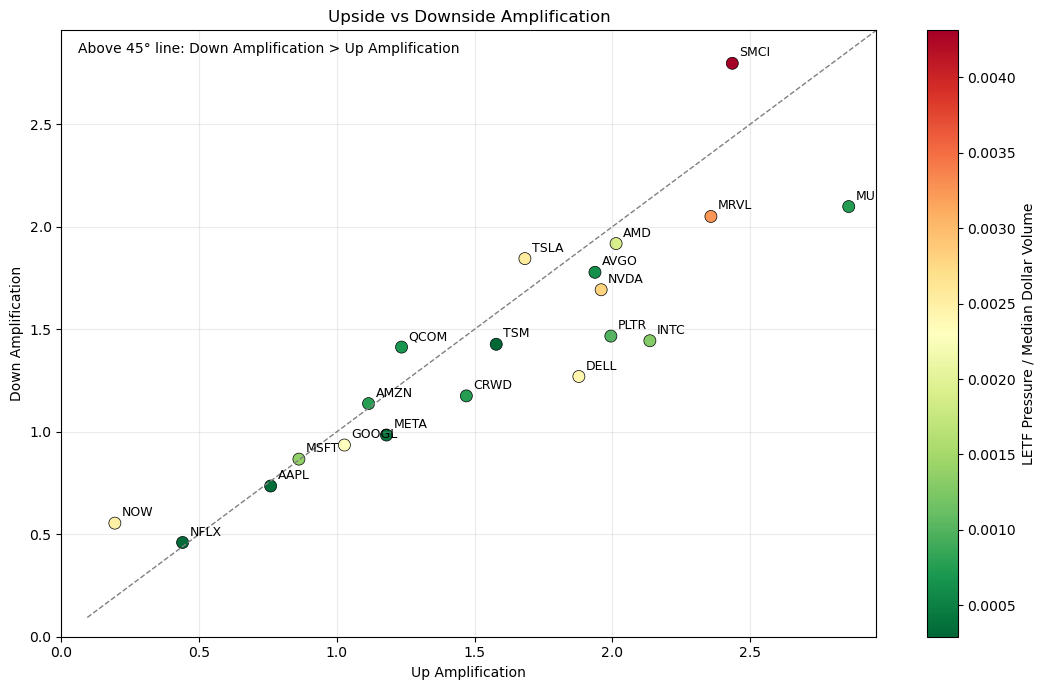

In [71]:
# WYKRES — UPSIDE vs DOWNSIDE AMPLIFICATION

# 1. PRZYGOTOWANIE DANYCH

plot_data = directional_results[
    [
        "Underlying",
        "Up Amplification",
        "Down Amplification",
        "Pressure / Median Volume"
    ]
].dropna().copy()


# 2. NORMALIZACJA PRESSURE / LIQUIDITY

norm = mpl.colors.Normalize(
    vmin=plot_data["Pressure / Median Volume"].min(),
    vmax=plot_data["Pressure / Median Volume"].max()
)


cmap = plt.cm.RdYlGn_r


# 3. WYKRES

fig, ax = plt.subplots(
    figsize=(11, 7)
)


scatter = ax.scatter(
    plot_data["Up Amplification"],
    plot_data["Down Amplification"],
    c=plot_data["Pressure / Median Volume"],
    cmap=cmap,
    norm=norm,
    s=75,
    edgecolor="black",
    linewidth=0.5
)


# 4. LINIA 45°

max_value = max(
    plot_data["Up Amplification"].max(),
    plot_data["Down Amplification"].max()
)

min_value = min(
    plot_data["Up Amplification"].min(),
    plot_data["Down Amplification"].min()
)

padding = 0.1

line_min = max(0, min_value - padding)
line_max = max_value + padding


ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    linewidth=1,
    color="gray"
)


# 5. ETYKIETY SPÓŁEK

for _, row in plot_data.iterrows():

    ax.annotate(
        row["Underlying"],
        (
            row["Up Amplification"],
            row["Down Amplification"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )


# 6. COLORBAR

cbar = plt.colorbar(
    scatter,
    ax=ax
)

cbar.set_label(
    "LETF Pressure / Median Dollar Volume"
)


# 7. OPIS WYKRESU

ax.set_xlabel(
    "Up Amplification"
)

ax.set_ylabel(
    "Down Amplification"
)

ax.set_title(
    "Upside vs Downside Amplification"
)


# 8. DODATKOWA INFORMACJA

ax.text(
    0.02,
    0.98,
    "Above 45° line: Down Amplification > Up Amplification",
    transform=ax.transAxes,
    va="top",
    fontsize=10
)


# 9. SIATKA

ax.grid(
    True,
    alpha=0.25
)


# 10. FORMATOWANIE

ax.set_xlim(
    0,
    line_max
)

ax.set_ylim(
    0,
    line_max
)


plt.tight_layout()

plt.show()